# New production defaults against the original production model

- `poly3_total` (original production): order-3 polynomial, cosmos_total, uniform SFH prior, dust index fixed at -0.7, tau Uniform(0, 2).
- `new_default`: same, plus StudentT(0, 0.3, df 2) on logsfr_ratios and a free dust index Uniform(-1.0, 0.4); the notebook with no env since 2026-09-06.
- `sfh_cont`, `dust_free`: each flip alone (stage 1). `new_default_rep1/2`: other NSS seeds, two galaxies, new-model floor.
- `tau_cn`: new_default with Ceridwen's documented ClippedNormal(0.3, 1.0, 0, 4) on tau. `dust_wide`: new_default with Uniform(-2.0, 0.5) on the index.
- Every arm uses identical pixels and bands, so ln Z is comparable throughout.

In [1]:
import os, sys, json, shutil, time
os.environ.setdefault("JAX_PLATFORMS", "cpu")
from pathlib import Path
import h5py
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
import corner
from astropy.table import Table

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", Path.cwd()))
while not (PROJECT_ROOT / "scripts" / "per_galaxy_diagnostics.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd
from build_dr2_quiescent_summary import FEH_OFFSET, formation_times
from spectral_figures import mark_absorption_features, spectral_tight_layout  # noqa: E402
from ceridwen.observation.stellar_indices import StellarIndices, LEGAC_DR2_STELLAR_INDEX_DEFINITIONS

REF_ROOT = PROJECT_ROOT / "results/calibration-polynomial-dr2"
TEST_ROOT = os.environ.get("CERIDWEN_KNOBS_RESULTS")  # scratch tree for test runs; unset in the committed execution
RESULTS = Path(TEST_ROOT) if TEST_ROOT else PROJECT_ROOT / "results/fit-accuracy-knobs"
WIKI_FIGURES = Path(TEST_ROOT) / "wiki" if TEST_ROOT else PROJECT_ROOT / "wiki/analyses/fit-accuracy-knobs"
REF_ARM, NEW_ARM = "poly3_total", "new_default"
OLD_REPS = ["seed_rep1", "seed_rep2", "seed_rep3"]
NEW_REPS = ["new_default_rep1", "new_default_rep2"]
SINGLE = ["sfh_cont", "dust_free"]
EXTRA = ["tau_cn", "dust_wide"]
MOCK_REF, MOCK_ARMS = "mock_tilt4_poly3", ["mock_tilt4_sfh_cont", "mock_tilt4_new_default"]
ROW_ORDER = [REF_ARM] + OLD_REPS + SINGLE + [NEW_ARM] + NEW_REPS + EXTRA
PHYSICS = ["age", "Z", "afe", "tau_dust", "logmass"]
F_FIXED_PCT = 3.0
FIXED_DUST_INDEX = -0.7
COLOURS = {REF_ARM: "k", "seed_rep1": "0.55", "seed_rep2": "0.65", "seed_rep3": "0.75", "sfh_cont": "tab:green", "dust_free": "tab:brown",
           NEW_ARM: "tab:blue", "new_default_rep1": "cornflowerblue", "new_default_rep2": "lightsteelblue",
           "tau_cn": "tab:orange", "dust_wide": "tab:purple", MOCK_REF: "0.4", "mock_tilt4_sfh_cont": "tab:green", "mock_tilt4_new_default": "tab:blue"}
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "Z": r"$[\mathrm{Fe}/\mathrm{H}]$", "afe": r"$[\alpha/\mathrm{Fe}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]", "t50": r"$t_{50}$ [Gyr]",
          "f_calib": r"$f_{\rm calib}$ [%]", "dust_index": r"$\delta_{\rm dust}$"}
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 80); pd.set_option("display.precision", 3)


def _text(v):
    return v.decode() if isinstance(v, bytes) else str(v)


def load_fit(folder):
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as d:
        out["attrs"] = dict(d.attrs)
        names = [_text(v) for v in d["summary/parameter"][:]]
        out["summary"] = pd.DataFrame({"q16": d["summary/q16"][:], "q50": d["summary/q50"][:], "q84": d["summary/q84"][:]}, index=names)
        out["diag"] = dict(d["diagnostics"].attrs)
        for grp in ("spectrum", "photometry", "sfh"):
            out[grp] = {k: d[grp][k][:] for k in d[grp]}
        out["truth"] = {k: np.asarray(d["mock_truth"][k][:]) for k in d["mock_truth"]} if "mock_truth" in d else None
    with h5py.File(folder / "ceridwen_result.h5", "r") as r:
        out["model_attrs"] = {k: _text(v) if isinstance(v, bytes) else v for k, v in r["model"].attrs.items()}
        out["n_calls"] = int(r["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(r["samples"].attrs["wall_time_s"])
    out["galaxy"] = pgd.load_galaxy(folder)
    return out


def find_fits():
    fits = {}
    roots = [REF_ROOT / REF_ARM, REF_ROOT / MOCK_REF] + [RESULTS / a for a in ROW_ORDER[1:] + MOCK_ARMS]
    for arm_dir in roots:
        if not arm_dir.is_dir():
            continue
        for folder in sorted(arm_dir.iterdir()):
            if (folder / "ceridwen_derived_outputs.h5").exists():
                fits[(arm_dir.name, folder.name.split("-", 1)[1])] = load_fit(folder)
    return fits


fits = find_fits()
galaxies = sorted({t for a, t in fits if a == REF_ARM}, key=lambda t: fits[(REF_ARM, t)]["attrs"]["catalogue_sn"])
arms_present = [a for a in ROW_ORDER if any(arm == a for arm, _ in fits)]
print(len(fits), "fits; galaxies:", galaxies)
print({a: sorted(t for arm, t in fits if arm == a) for a in arms_present + [MOCK_REF] + MOCK_ARMS if any(arm == a for arm, _ in fits)})

48 fits; galaxies: ['M12_98104', 'M5_173928', 'M4_108989', 'M12_185653', 'M1_206545', 'M5_172669']
{'poly3_total': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'seed_rep1': ['M4_108989', 'M5_172669'], 'seed_rep2': ['M4_108989', 'M5_172669'], 'seed_rep3': ['M4_108989', 'M5_172669'], 'sfh_cont': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'dust_free': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'new_default': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'new_default_rep1': ['M4_108989', 'M5_172669'], 'new_default_rep2': ['M4_108989', 'M5_172669'], 'tau_cn': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'dust_wide': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'mock_tilt4_poly3': ['M5_172669'], 'mock_tilt4_sfh_cont': ['M5_172669']}


## Per-fit table

- Raw chi2 at f_calib = 3% on the fit's own pixels; stored chi2 uses the fitted floor.
- `dust_index` from the sampled posterior where the index is free; `dust_rail_lo` is the posterior mass within 5% of the lower prior edge.
- Priors read back from the h5 model attributes.

In [2]:
SWITCHES = ["free_dust_index", "sfh_prior", "tau_prior", "dust_index_bounds"]


def half_width(row):
    return 0.5 * (row["q84"] - row["q16"])


def chi2_at_f(fit, f_pct, mask=None):
    s = fit["spectrum"]
    mask = s["mask"].astype(bool) if mask is None else mask
    sigma = np.hypot(s["uncertainty"], (f_pct / 100.0) * np.abs(s["posterior_q50"]))
    return float(np.sum(((s["observed"] - s["posterior_q50"]) / sigma)[mask] ** 2))


def phot_chi2(fit, mask=None):
    p = fit["photometry"]
    mask = p["mask"].astype(bool) if mask is None else mask
    return float(np.sum(p["pull"][mask] ** 2))


def mw_age_samples(g):
    r = np.asarray(g.samples["logsfr_ratios"])
    h = 10.0 ** np.concatenate([np.zeros((len(r), 1)), -np.cumsum(r, axis=1)], axis=1)
    edges = g.sfh_edges_gyr
    m = 0.5 * (h[:, :-1] + h[:, 1:]) * np.diff(edges)
    return (m * (0.5 * (edges[:-1] + edges[1:]))).sum(1) / m.sum(1)


def wq(g, values, q=(0.16, 0.5, 0.84)):
    w = pgd.posterior_weights(g)
    return np.array([pgd.weighted_quantile(values, w, p) for p in q])


def dust_bounds(fit):
    text = fit["model_attrs"].get("dust_index_bounds", "-1.0,0.4")
    return tuple(float(x) for x in str(text).split(","))


def derived_row(arm, target, fit):
    g, summ, spec = fit["galaxy"], fit["summary"], fit["spectrum"]
    mask = spec["mask"].astype(bool)
    row = dict(arm=arm, target=target, z=fit["attrs"]["redshift"], sn=fit["attrs"]["catalogue_sn"], seed=g.seed,
               n_pix=int(mask.sum()), n_bands=int(fit["photometry"]["mask"].astype(bool).sum()),
               spec_chi2_stored=float(fit["diag"]["spectrum_chi2"]), spec_chi2_raw3=chi2_at_f(fit, F_FIXED_PCT),
               phot_chi2=float(fit["diag"]["photometry_chi2"]),
               lnZ=float(fit["diag"]["log_evidence"]), lnZ_err=float(fit["diag"]["log_evidence_err"]),
               ess=float(fit["diag"]["posterior_weight_ess"]), passed=bool(fit["diag"]["passed"]),
               calls=fit["n_calls"], wall_s=fit["wall_s"])
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]"), ("scaling", "spectrum_scaling")]:
        row[f"{name}_q50"], row[f"{name}_hw"] = summ.loc[key, "q50"], half_width(summ.loc[key])
    row["Z_q50"] += FEH_OFFSET  # grid Z -> [Fe/H]
    t20, t50, t80 = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    q16, q50, q84 = np.percentile(t50, [16, 50, 84])
    row["t50_q50"], row["t50_hw"] = q50, 0.5 * (q84 - q16)
    if "diffuse_dust_index" in g.samples:
        idx = np.asarray(g.samples["diffuse_dust_index"]); w = pgd.posterior_weights(g)
        lo, mid, hi = wq(g, idx)
        b_lo, b_hi = dust_bounds(fit); span = b_hi - b_lo
        row["dust_index_q50"], row["dust_index_hw"] = mid, 0.5 * (hi - lo)
        row["dust_rail_lo"] = float(w[idx < b_lo + 0.05 * span].sum())
        row["dust_rail_hi"] = float(w[idx > b_hi - 0.05 * span].sum())
    for key in SWITCHES:
        if key in fit["model_attrs"]:
            row[key] = fit["model_attrs"][key]
    return row


table = pd.DataFrame([derived_row(a, t, f) for (a, t), f in fits.items()]).set_index(["target", "arm"]).sort_index()
table.to_csv(RESULTS / "new-defaults-fits.csv")
check = {t: wq(fits[(REF_ARM, t)]["galaxy"], mw_age_samples(fits[(REF_ARM, t)]["galaxy"]))[1] / table.loc[(t, REF_ARM), "age_q50"] - 1 for t in galaxies}
assert max(abs(v) for v in check.values()) < 0.02, check
show = ["seed", "spec_chi2_raw3", "phot_chi2", "lnZ", "f_calib_q50", "age_q50", "age_hw", "Z_q50", "Z_hw", "afe_q50", "afe_hw",
        "tau_dust_q50", "tau_dust_hw", "logmass_q50", "logmass_hw", "dust_index_q50", "dust_index_hw", "dust_rail_lo", "sfh_prior", "tau_prior", "dust_index_bounds", "wall_s"]
table[[c for c in show if c in table]]

seed  spec_chi2_raw3  phot_chi2         lnZ  f_calib_q50  age_q50  age_hw      Z_q50   Z_hw  afe_q50  afe_hw  tau_dust_q50  tau_dust_hw  logmass_q50  logmass_hw  dust_index_q50  dust_index_hw  dust_rail_lo  \
target     arm                                                                                                                                                                                                                                      
M12_185653 dust_free            20260923        7131.318      4.638  233877.088        6.312    4.800   0.420 -4.354e-01  0.087    0.207   0.038         0.312        0.045       11.125       0.043       2.958e-01          0.105     2.258e-05   
           dust_wide            20260923        7131.366      4.198  233874.907        6.309    4.939   0.375 -4.366e-01  0.068    0.220   0.034         0.313        0.049       11.135       0.036       3.016e-01          0.168     3.777e-09   
           new_default          20260923        7132.440      4.386  233875.373        6.309    5.003   0.337 -4.387e-01  0.072    0.213   0.035         0.306        0.047       11.136       0.036       2.574e-01          0.136     4.168e-05   
           poly3_total          20260923        7133.733     11.112  233871.325        6.317    5.017   0.370 -4.481e-01  0.079    0.228   0.033         0.172        0.029       11.100       0.035             NaN            NaN           NaN   
           sfh_cont             20260923        7136.580     10.074  233870.058        6.308    4.886   0.420 -3.992e-01  0.074    0.223   0.035         0.178        0.028       11.083       0.043             NaN            NaN           NaN   
           tau_cn               20260923        7134.537      4.064  233875.472        6.315    4.824   0.344 -4.175e-01  0.064    0.206   0.033         0.307        0.048       11.120       0.033       2.386e-01          0.150     5.551e-05   
M12_98104  dust_free            20261007        8250.235      4.111  249684.406        9.985    4.438   0.118 -8.304e-01  0.068    0.125   0.053         0.533        0.067       11.306       0.031      -2.686e-04          0.162     5.920e-06   
           dust_wide            20261007        8249.535      4.408  249681.284        9.983    4.569   0.186 -8.276e-01  0.084    0.127   0.049         0.515        0.082       11.303       0.037      -7.359e-02          0.204     3.569e-13   
           new_default          20261007        8247.560      4.318  249681.773        9.982    4.512   0.221 -8.018e-01  0.083    0.138   0.049         0.494        0.073       11.293       0.037      -8.891e-02          0.196     7.929e-04   
           poly3_total          20261007        8241.728     10.090  249681.232        9.978    4.403   0.267 -7.408e-01  0.075    0.140   0.055         0.363        0.035       11.248       0.026             NaN            NaN           NaN   
           sfh_cont             20261007        8244.311      9.544  249680.485        9.984    4.516   0.253 -7.231e-01  0.077    0.150   0.051         0.368        0.031       11.252       0.029             NaN            NaN           NaN   
           tau_cn               20261007        8247.086      4.591  249681.940        9.981    4.516   0.243 -7.900e-01  0.090    0.134   0.048         0.492        0.072       11.290       0.035      -1.105e-01          0.205     7.513e-04   
M1_206545  dust_free            20260877        5200.380     47.938  222950.037        3.882    5.065   0.018 -7.020e-02  0.021   -0.189   0.009         0.385        0.017       11.621       0.010      -9.877e-01          0.014     9.830e-01   
           dust_wide            20260877        5169.116     37.550  222967.002        3.830    5.198   0.080  3.016e-02  0.026   -0.173   0.012         0.201        0.017       11.591       0.011      -1.896e+00          0.096     5.773e-01   
           new_default          20260877        5203.055     48.789  222942.819        3.880    5.163   0.093 -7.409

## Deltas

- Against `poly3_total`: shifts in poly3 half-widths, chi2 and ln Z differences. Old seed floor = largest repeat shift over `seed_rep1..3`.
- Against `new_default`: `new_default_rep1/2`, `tau_cn`, `dust_wide` in new_default half-widths. New floor from the two new repeats.

In [3]:
def delta_rows(base_arm, arms):
    rows = []
    for (arm, target), fit in fits.items():
        if arm not in arms or (base_arm, target) not in fits:
            continue
        ref = fits[(base_arm, target)]
        smask = ref["spectrum"]["mask"].astype(bool) & fit["spectrum"]["mask"].astype(bool)
        cur, base = table.loc[(target, arm)], table.loc[(target, base_arm)]
        row = dict(target=target, arm=arm, base=base_arm,
                   same_data=bool(smask.sum() == ref["spectrum"]["mask"].sum() == fit["spectrum"]["mask"].sum()),
                   dchi2_raw3=chi2_at_f(fit, F_FIXED_PCT, smask) - chi2_at_f(ref, F_FIXED_PCT, smask),
                   dchi2_phot=phot_chi2(fit) - phot_chi2(ref),
                   dlnZ=cur["lnZ"] - base["lnZ"], dlnZ_sig=(cur["lnZ"] - base["lnZ"]) / np.hypot(cur["lnZ_err"], base["lnZ_err"]),
                   df_calib=cur["f_calib_q50"] - base["f_calib_q50"])
        for p in PHYSICS:
            row[f"shift_{p}"] = (cur[f"{p}_q50"] - base[f"{p}_q50"]) / base[f"{p}_hw"]
            row[f"hw_ratio_{p}"] = cur[f"{p}_hw"] / base[f"{p}_hw"]
        if "dust_index_q50" in cur and np.isfinite(cur.get("dust_index_q50", np.nan)) and np.isfinite(base.get("dust_index_q50", np.nan)):
            row["shift_dust_index"] = (cur["dust_index_q50"] - base["dust_index_q50"]) / base["dust_index_hw"]
        rows.append(row)
    return pd.DataFrame(rows).set_index(["target", "arm"]).sort_index()


shift_cols = [f"shift_{p}" for p in PHYSICS]
vs_old = delta_rows(REF_ARM, OLD_REPS + SINGLE + [NEW_ARM] + NEW_REPS + EXTRA)
vs_new = delta_rows(NEW_ARM, NEW_REPS + EXTRA)
vs_old.to_csv(RESULTS / "new-defaults.csv"); vs_new.to_csv(RESULTS / "new-defaults-vs-new.csv")
assert vs_old["same_data"].all() and vs_new["same_data"].all()


def floor_of(deltas, reps):
    sub = deltas[deltas.index.get_level_values("arm").isin(reps)]
    f = pd.DataFrame({"max |shift|": sub[shift_cols].abs().max().to_numpy(), "rms shift": np.sqrt((sub[shift_cols] ** 2).mean()).to_numpy(),
                      "n repeats": sub[shift_cols].notna().sum().to_numpy()}, index=PHYSICS)
    f.loc["dust_index"] = [sub["shift_dust_index"].abs().max(), np.sqrt((sub["shift_dust_index"] ** 2).mean()), sub["shift_dust_index"].notna().sum()] if "shift_dust_index" in sub else [np.nan] * 3
    f.loc["lnZ"] = [sub["dlnZ"].abs().max(), np.sqrt((sub["dlnZ"] ** 2).mean()), len(sub)]
    return f


floor_old, floor_new = floor_of(vs_old, OLD_REPS), floor_of(vs_new, NEW_REPS)
floors = pd.concat({"old model (poly3_total reps)": floor_old, "new model (new_default reps)": floor_new}, axis=1)
floors.to_csv(RESULTS / "seed-floors.csv")
floors

old model (poly3_total reps)                     new model (new_default reps)                    
                            max |shift| rms shift n repeats                  max |shift| rms shift n repeats
age                               1.197     0.527       6.0                        0.336     0.241       4.0
Z                                 0.487     0.295       6.0                        0.540     0.271       4.0
afe                               0.956     0.461       6.0                        0.232     0.165       4.0
tau_dust                          0.316     0.178       6.0                        0.068     0.042       4.0
logmass                           0.489     0.228       6.0                        0.286     0.222       4.0
dust_index                          NaN       NaN       NaN                        0.150     0.088       4.0
lnZ                               1.986     0.880       6.0                        3.133     2.316       4.0

## New defaults against the original production model, per galaxy

- Medians old and new; shift in poly3 half-widths; `> old floor` flags a move beyond the largest seed-repeat shift.
- ln Z and chi2 differences on identical data.

In [4]:
rows = []
for t in galaxies:
    if (t, NEW_ARM) not in table.index:
        continue
    old, new, d = table.loc[(t, REF_ARM)], table.loc[(t, NEW_ARM)], vs_old.loc[(t, NEW_ARM)]
    row = dict(target=t, sn=old["sn"])
    for p in PHYSICS:
        row[f"{p} old"], row[f"{p} new"], row[f"{p} shift"] = old[f"{p}_q50"], new[f"{p}_q50"], d[f"shift_{p}"]
        row[f"{p} > old floor"] = abs(d[f"shift_{p}"]) > floor_old.loc[p, "max |shift|"]
        row[f"{p} hw ratio"] = d[f"hw_ratio_{p}"]
    row["dust index new"], row["dust index hw"], row["dust rail lo"] = new.get("dust_index_q50"), new.get("dust_index_hw"), new.get("dust_rail_lo")
    row["dlnZ"], row["dlnZ_sig"], row["dchi2_raw3"], row["dchi2_phot"] = d["dlnZ"], d["dlnZ_sig"], d["dchi2_raw3"], d["dchi2_phot"]
    rows.append(row)
headline = pd.DataFrame(rows).set_index("target")
headline.to_csv(RESULTS / "new-defaults-headline.csv")
print("galaxy-parameter pairs beyond the old floor:", int(headline[[c for c in headline if c.endswith("> old floor")]].sum().sum()), "of", len(headline) * len(PHYSICS))
print("median hw ratio new/old:", {p: round(float(headline[f"{p} hw ratio"].median()), 2) for p in PHYSICS})
headline[[c for c in headline if "hw ratio" not in c]]

galaxy-parameter pairs beyond the old floor: 18 of 30
median hw ratio new/old: {'age': 1.93, 'Z': 1.05, 'afe': 1.08, 'tau_dust': 1.26, 'logmass': 1.4}


,sn,age old,age new,age shift,age > old floor,Z old,Z new,Z shift,Z > old floor,afe old,afe new,afe shift,afe > old floor,tau_dust old,tau_dust new,tau_dust shift,tau_dust > old floor,logmass old,logmass new,logmass shift,logmass > old floor,dust index new,dust index hw,dust rail lo,dlnZ,dlnZ_sig,dchi2_raw3,dchi2_phot
target,,,,,,,,,,,,,,,,,,,,,,,,,,,,
M12_98104,6.6,4.403,4.512,0.407,False,-0.741,-0.802,-0.819,True,0.140,0.138,-0.033,False,0.363,0.494,3.727,True,11.248,11.293,1.707,True,-0.089,0.196,7.929e-04,0.542,2.107,5.831,-5.771
M5_173928,13.3,4.499,4.932,4.107,True,-0.501,-0.494,0.391,False,-0.141,-0.118,0.946,False,0.541,0.450,-4.730,True,11.716,11.721,0.448,False,-0.979,0.027,8.842e-01,5.564,15.365,-14.776,-12.399
M4_108989,21.3,4.610,4.703,0.804,False,-0.145,-0.171,-0.879,True,-0.190,-0.192,-0.179,False,0.253,0.348,3.400,True,11.811,11.840,1.848,True,0.107,0.287,2.486e-02,-3.157,-7.972,5.403,0.057
M12_185653,21.5,5.017,5.003,-0.039,False,-0.448,-0.439,0.119,False,0.228,0.213,-0.478,False,0.172,0.306,4.620,True,11.100,11.136,1.016,True,0.257,0.136,4.168e-05,4.049,12.396,-1.293,-6.727
M1_206545,31.4,5.065,5.163,6.759,True,-0.119,-0.074,1.956,True,-0.193,-0.189,0.682,False,0.457,0.390,-3.174,True,11.638,11.630,-0.839,True,-0.987,0.016,9.803e-01,7.590,17.253,-27.875,-15.849
M5_172669,105.0,1.846,2.484,6.426,True,0.144,0.162,0.613,True,-0.050,-0.058,-0.608,False,0.577,0.470,-5.586,True,11.329,11.343,1.227,True,-0.975,0.026,8.854e-01,8.956,20.114,-3.291,-39.669


## Both flips together against each alone

- Shift of `new_default` against `poly3_total` beside `sfh_cont` and `dust_free`, in poly3 half-widths.
- Additivity check: (sfh_cont shift + dust_free shift) - new_default shift.

In [5]:
parts = vs_old[shift_cols + ["dlnZ"]].unstack("arm")
combo = {}
for p in PHYSICS + ["lnZ"]:
    col = f"shift_{p}" if p != "lnZ" else "dlnZ"
    for arm in SINGLE + [NEW_ARM]:
        if (col, arm) in parts:
            combo[(p, arm)] = parts[(col, arm)]
    if all((col, a) in parts for a in SINGLE + [NEW_ARM]):
        combo[(p, "sum - both")] = parts[(col, "sfh_cont")] + parts[(col, "dust_free")] - parts[(col, NEW_ARM)]
combo = pd.DataFrame(combo)
combo.to_csv(RESULTS / "new-defaults-additivity.csv")
combo.round(2)

age                                         Z                                       afe                                  tau_dust                                   logmass                                       lnZ            \
           sfh_cont dust_free new_default sum - both sfh_cont dust_free new_default sum - both sfh_cont dust_free new_default sum - both sfh_cont dust_free new_default sum - both sfh_cont dust_free new_default sum - both sfh_cont dust_free   
target                                                                                                                                                                                                                                            
M12_185653    -0.35     -0.58       -0.04      -0.90     0.62      0.16        0.12       0.66    -0.16     -0.66       -0.48      -0.34     0.20      4.85        4.62       0.43    -0.49      0.71        1.02      -0.80    -1.27      5.76   
M12_98104      0.42      0.13        0.41       0.15     0.24     -1.20       -0.82      -0.15     0.19     -0.26       -0.03      -0.03     0.14      4.82        3.73       1.24     0.13      2.18        1.71       0.60    -0.75      3.17   
M1_206545      7.00     -0.01        6.76       0.24    -0.26      2.13        1.96      -0.09     0.03      0.72        0.68       0.07     0.09     -3.40       -3.17      -0.13     0.60     -1.76       -0.84      -0.32    -6.76     14.81   
M4_108989      1.22     -0.14        0.80       0.28    -0.11     -0.99       -0.88      -0.22     0.17     -0.28       -0.18       0.07    -0.40      3.02        3.40      -0.78     0.36      1.29        1.85      -0.20    -4.15      0.76   
M5_172669      5.05      0.02        6.43      -1.35    -0.18      0.59        0.61      -0.20    -0.99     -0.33       -0.61      -0.71    -0.30     -5.17       -5.59       0.11     2.96     -1.96        1.23      -0.23    -4.78     11.34   
M5_173928      2.90      2.54        4.11       1.33    -1.78      0.56        0.39      -1.61     0.32      0.87        0.95       0.25     0.12     -4.89       -4.73      -0.04     2.05     -0.84        0.45       0.77    -5.23     10.60   

                                   
           new_default sum - both  
target                             
M12_185653        4.05       0.45  
M12_98104         0.54       1.89  
M1_206545         7.59       0.45  
M4_108989        -3.16      -0.23  
M5_172669         8.96      -2.39  
M5_173928         5.56      -0.19

## tau_cn and dust_wide against new_default

- Shifts in new_default half-widths; `> new floor` compares with the two new-model repeats.
- `dust_wide`: does the index leave the -1.0 wall (rail mass at the lower edge, old bounds against new).

In [6]:
extra_rows = []
for (t, arm), d in vs_new.iterrows():
    if arm not in EXTRA:
        continue
    cur, base = table.loc[(t, arm)], table.loc[(t, NEW_ARM)]
    row = dict(target=t, arm=arm, dlnZ=d["dlnZ"], dlnZ_sig=d["dlnZ_sig"], dchi2_raw3=d["dchi2_raw3"], dchi2_phot=d["dchi2_phot"])
    for p in PHYSICS:
        row[f"{p} shift"] = d[f"shift_{p}"]; row[f"{p} > new floor"] = abs(d[f"shift_{p}"]) > floor_new.loc[p, "max |shift|"]
    row.update({"tau new": base["tau_dust_q50"], "tau arm": cur["tau_dust_q50"],
                "index new": base.get("dust_index_q50"), "index arm": cur.get("dust_index_q50"), "index hw arm": cur.get("dust_index_hw"),
                "rail lo new": base.get("dust_rail_lo"), "rail lo arm": cur.get("dust_rail_lo")})
    extra_rows.append(row)
extra = pd.DataFrame(extra_rows).set_index(["arm", "target"]).sort_index() if extra_rows else pd.DataFrame()
extra.to_csv(RESULTS / "new-defaults-extra-arms.csv")
if len(extra):
    for arm in EXTRA:
        if arm in extra.index.get_level_values("arm"):
            sub = extra.xs(arm, level="arm")
            print(arm, "pairs beyond the new floor:", int(sub[[c for c in sub if c.endswith("> new floor")]].sum().sum()), "of", len(sub) * len(PHYSICS),
                  "| median dlnZ", round(float(sub["dlnZ"].median()), 2))
extra

tau_cn pairs beyond the new floor: 7 of 30 | median dlnZ 0.0
dust_wide pairs beyond the new floor: 19 of 30 | median dlnZ 12.09


dlnZ  dlnZ_sig  dchi2_raw3  dchi2_phot  age shift  age > new floor  Z shift  Z > new floor  afe shift  afe > new floor  tau_dust shift  tau_dust > new floor  logmass shift  logmass > new floor  tau new  tau arm  index new  \
arm       target                                                                                                                                                                                                                                        
dust_wide M12_185653  -0.466    -1.498      -1.074      -0.187     -0.188            False    0.029          False      0.208            False           0.157                  True         -0.026                False    0.306    0.313      0.257   
          M12_98104   -0.490    -1.832       1.976       0.090      0.261            False   -0.309          False     -0.213            False           0.289                  True          0.258                False    0.494    0.515     -0.089   
          M1_206545   24.183    51.832     -33.940     -11.240      0.371             True    4.603           True      2.023             True         -11.654                  True         -3.322                 True    0.390    0.201     -0.987   
          M4_108989   28.040    63.318    -121.551      10.739     -5.978             True   12.246           True      4.278             True          -3.012                  True         -4.443                 True    0.348    0.165      0.107   
          M5_172669   -0.011    -0.034       0.439     -15.147      0.122            False   -0.068          False     -0.228            False          -3.725                  True         -0.369                 True    0.470    0.410     -0.975   
          M5_173928   31.262    75.462      11.747      53.337     -4.391             True   24.305           True     -1.667             True          -8.787                  True         -6.583                 True    0.450    0.295     -0.979   
tau_cn    M12_185653   0.099     0.424       2.097      -0.321     -0.529             True    0.294          False     -0.178            False           0.022                 False         -0.432                 True    0.306    0.307      0.257   
          M12_98104    0.167     0.548      -0.474       0.272      0.017            False    0.142          False     -0.083            False          -0.033                 False         -0.086                False    0.494    0.492     -0.089   
          M1_206545   -0.095    -0.218      -0.759       0.009      0.273            False   -0.146          False      0.183            False          -0.120                  True         -0.055                False    0.390    0.388     -0.987   
          M4_108989    0.479     1.286       1.789       0.211     -0.044            False   -0.040          False      0.061            False           0.052                 False         -0.068                False    0.348    0.351      0.107   
          M5_172669   -1.543    -4.030       0.041       0.719      0.009            False   -0.158          False     -0.128            False           0.052                 False          0.042                False    0.470    0.470     -0.975   
          M5_173928   -0.592    -1.361       3.111      -0.499     -0.388             True    0.059          False     -0.442             True          -0.321                  True         -0.447                 True    0.450    0.444     -0.979   

                      index arm  index hw arm  rail lo new  rail lo arm  
arm       target                                                         
dust_wide M12_185653      0.302         0.168    4.168e-05    3.777e-09  
          M12_98104      -0.074         0.204    7.929e-04    3.569e-13  
          M1_206545      -1.896         0.096    9.803e-01    5.773e-01  
          M4_108989      -1.938         0.066    2.486e-02    7.831e-01  
          M5_172669      -1.142         0.083    8.854e-01    1.507e-16  
          M5_173928

## Dust index posteriors

- Weighted histograms per galaxy for every arm with a free index; dashed line at the fixed -0.7 of the original model.
- Prior edges drawn per arm: -1.0 to 0.4 (new default) and -2.0 to 0.5 (dust_wide).

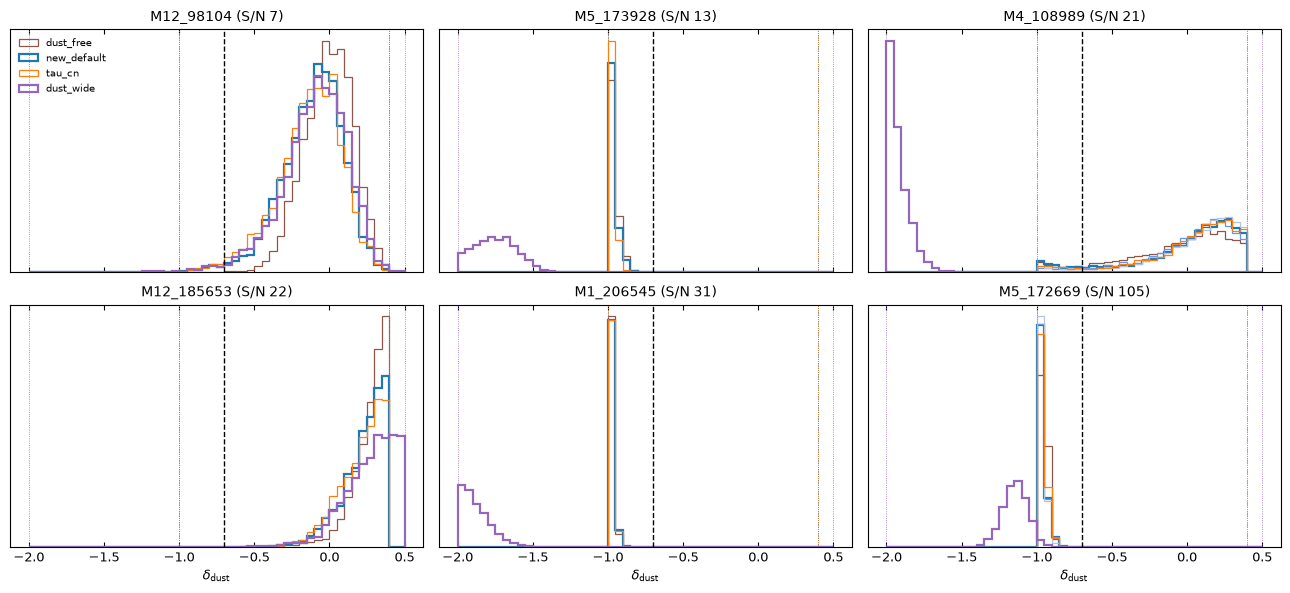

dust_index_q50  dust_index_hw  dust_rail_lo  dust_rail_hi  tau_dust_q50  tau_dust_hw dust_index_bounds
target     arm                                                                                                                     
M12_98104  dust_free             -2.686e-04          0.162     5.920e-06     8.262e-03         0.533        0.067               NaN
           new_default           -8.891e-02          0.196     7.929e-04     3.037e-03         0.494        0.073          -1.0,0.4
           tau_cn                -1.105e-01          0.205     7.513e-04     1.815e-03         0.492        0.072          -1.0,0.4
           dust_wide             -7.359e-02          0.204     3.569e-13     2.733e-03         0.515        0.082          -2.0,0.5
M5_173928  dust_free             -9.710e-01          0.030     8.448e-01     5.613e-49         0.447        0.019               NaN
           new_default           -9.788e-01          0.027     8.842e-01     7.153e-52         0.450        0.018          -1.0,0.4
           tau_cn                -9.809e-01          0.020     9.531e-01     2.858e-65         0.444        0.016          -1.0,0.4
           dust_wide             -1.752e+00          0.145     2.034e-01     2.676e-75         0.295        0.026          -2.0,0.5
M4_108989  dust_free              2.053e-02          0.338     2.309e-02     7.628e-02         0.337        0.066               NaN
           new_default            1.066e-01          0.287     2.486e-02     1.023e-01         0.348        0.060          -1.0,0.4
           new_default_rep1       9.455e-02          0.258     8.534e-03     8.302e-02         0.345        0.057          -1.0,0.4
           new_default_rep2       1.281e-01          0.258     1.370e-02     1.194e-01         0.349        0.061          -1.0,0.4
           tau_cn                 1.093e-01          0.268     1.544e-02     1.063e-01         0.351        0.056          -1.0,0.4
           dust_wide             -1.938e+00          0.066     7.831e-01     1.755e-14         0.165        0.012          -2.0,0.5
M12_185653 dust_free              2.958e-01          0.105     2.258e-05     3.615e-01         0.312        0.045               NaN
           new_default            2.574e-01          0.136     4.168e-05     2.701e-01         0.306        0.047          -1.0,0.4
           tau_cn                 2.386e-01          0.150     5.551e-05     2.308e-01         0.307        0.048          -1.0,0.4
           dust_wide              3.016e-01          0.168     3.777e-09     3.176e-01         0.313        0.049          -2.0,0.5
M1_206545  dust_free             -9.877e-01          0.014     9.830e-01     4.790e-40         0.385        0.017               NaN
           new_default           -9.871e-01          0.016     9.803e-01     9.681e-35         0.390        0.016          -1.0,0.4
           tau_cn                -9.870e-01          0.015     9.753e-01     3.312e-36         0.388        0.016          -1.0,0.4
           dust_wide             -1.896e+00          0.096     5.773e-01     5.649e-53         0.201        0.017          -2.0,0.5
M5_172669  dust_free             -9.584e-01          0.029     8.291e-01     2.000e-75         0.478        0.017               NaN
           new_default           -9.747e-01          0.026     8.854e-01    8.212e-114         0.470        0.016          -1.0,0.4
           new_default_rep1      -9.738e-01          0.025     9.021e-01     1.272e-99         0.471        0.018          -1.0,0.4
           new_default_rep2      -9.786e-01          0.024     9.271e-01    1.533e-113         0.470        0.016          -1.0,0.4
           tau_cn                -9.738e-01          0.028     8.695e-01    8.646e-134         0.470        0.017          -1.0,0.4
           dust_wide             -1.142e+00          0.083     1.507e-16    1.366e-107         0.410        0.030          -2.0,0.5

In [7]:
DUST_ARMS = [a for a in ["dust_free", NEW_ARM] + NEW_REPS + EXTRA if a in arms_present]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, t in zip(axes.ravel(), galaxies):
    for arm in DUST_ARMS:
        if (arm, t) not in fits or "diffuse_dust_index" not in fits[(arm, t)]["galaxy"].samples:
            continue
        g = fits[(arm, t)]["galaxy"]; b = dust_bounds(fits[(arm, t)])
        ax.hist(np.asarray(g.samples["diffuse_dust_index"]), weights=pgd.posterior_weights(g), bins=np.linspace(-2.0, 0.5, 51), density=True,
                histtype="step", color=COLOURS[arm], lw=1.6 if arm in (NEW_ARM, "dust_wide") else 0.9, label=arm)
        for edge in b:
            ax.axvline(edge, color=COLOURS[arm], lw=0.6, ls=":")
    ax.axvline(FIXED_DUST_INDEX, color="k", lw=1.0, ls="--")
    ax.set_title(f"{t} (S/N {fits[(REF_ARM, t)]['attrs']['catalogue_sn']:.0f})", fontsize=10); ax.set_yticks([])
for ax in axes[-1]:
    ax.set_xlabel(LABELS["dust_index"])
axes[0, 0].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(RESULTS / "nd-dust-index.png", dpi=130); plt.show()
dust = table.loc[[(t, a) for t in galaxies for a in DUST_ARMS if (t, a) in table.index], ["dust_index_q50", "dust_index_hw", "dust_rail_lo", "dust_rail_hi", "tau_dust_q50", "tau_dust_hw", "dust_index_bounds"]]
dust.to_csv(RESULTS / "dust-index.csv")
dust

## Parameter shifts

- Point: median; bar: 16-84 range; one row per arm. Grey band: poly3 median +- the old seed floor.
- Last column: dust index; the original model sits at the fixed -0.7 (cross).

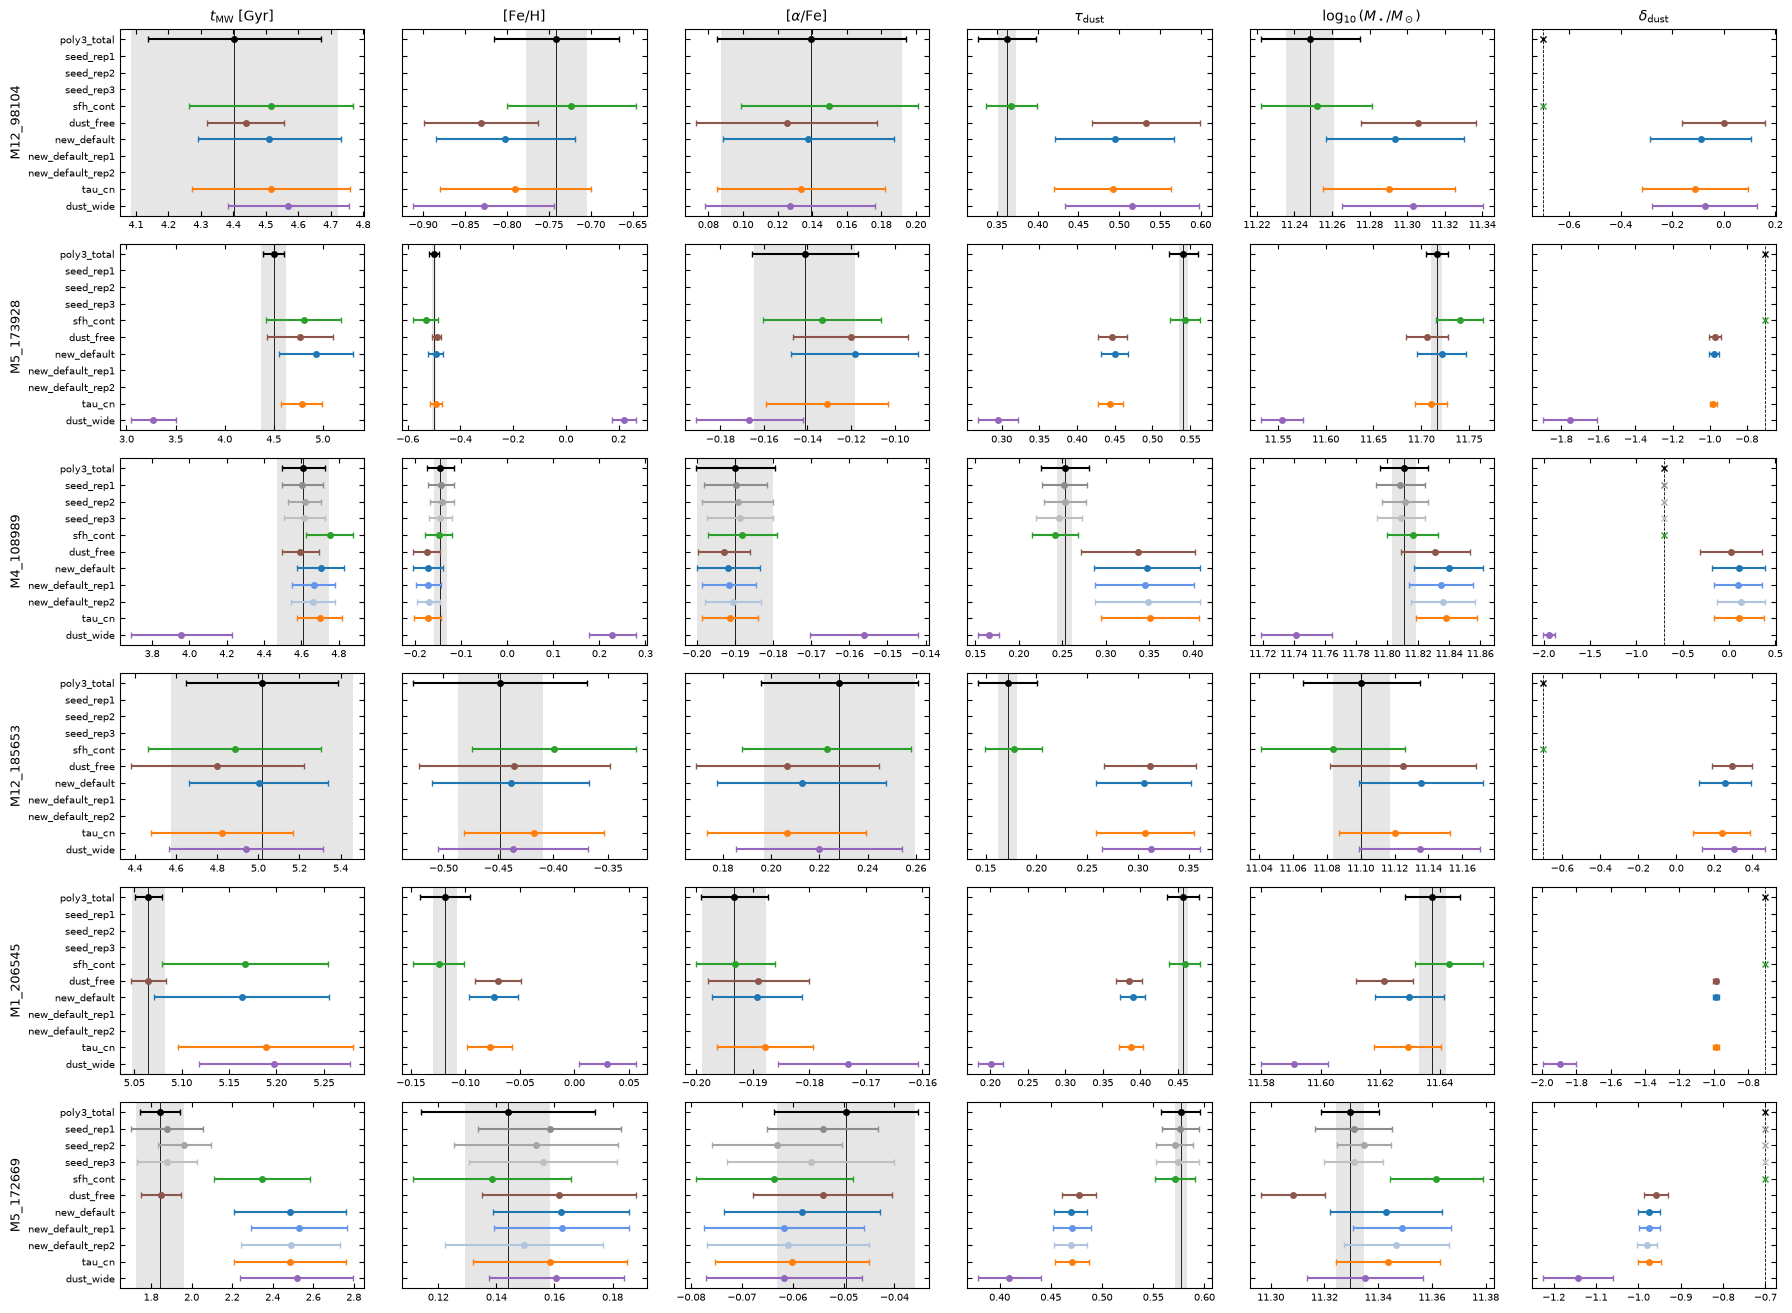

In [8]:
cols = PHYSICS + ["dust_index"]
fig, axes = plt.subplots(len(galaxies), len(cols), figsize=(3.0 * len(cols), 2.2 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    base = table.loc[(target, REF_ARM)]
    for c, name in enumerate(cols):
        ax = axes[r, c]
        if name != "dust_index":
            band = floor_old.loc[name, "max |shift|"] * base[f"{name}_hw"]
            ax.axvspan(base[f"{name}_q50"] - band, base[f"{name}_q50"] + band, color="0.9", lw=0)
            ax.axvline(base[f"{name}_q50"], color="k", lw=0.6)
        else:
            ax.axvline(FIXED_DUST_INDEX, color="k", lw=0.6, ls="--")
        for i, arm in enumerate(arms_present):
            if (target, arm) not in table.index:
                continue
            row = table.loc[(target, arm)]
            if name == "dust_index" and not np.isfinite(row.get("dust_index_q50", np.nan)):
                ax.plot(FIXED_DUST_INDEX, i, "x", color=COLOURS[arm], ms=5)
                continue
            ax.errorbar(row[f"{name}_q50"], i, xerr=row[f"{name}_hw"], fmt="o", ms=4, color=COLOURS[arm], capsize=2)
        ax.set_yticks(range(len(arms_present))); ax.set_yticklabels(arms_present if c == 0 else [""] * len(arms_present), fontsize=7)
        ax.set_ylim(-0.6, len(arms_present) - 0.4); ax.invert_yaxis(); ax.tick_params(axis="x", labelsize=7)
        if r == 0:
            ax.set_title(LABELS[name], fontsize=10)
        if c == 0:
            ax.set_ylabel(target, fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS / "nd-parameters-shift.png", dpi=130); plt.show()

## Star-formation histories, old against new

- Left: median SFR at the lookback nodes per unit formed mass; bands 16-84 for poly3_total (grey) and new_default (blue).
- Right: mass fraction formed younger than each lookback time. Thin lines: tau_cn, dust_wide, single flips.

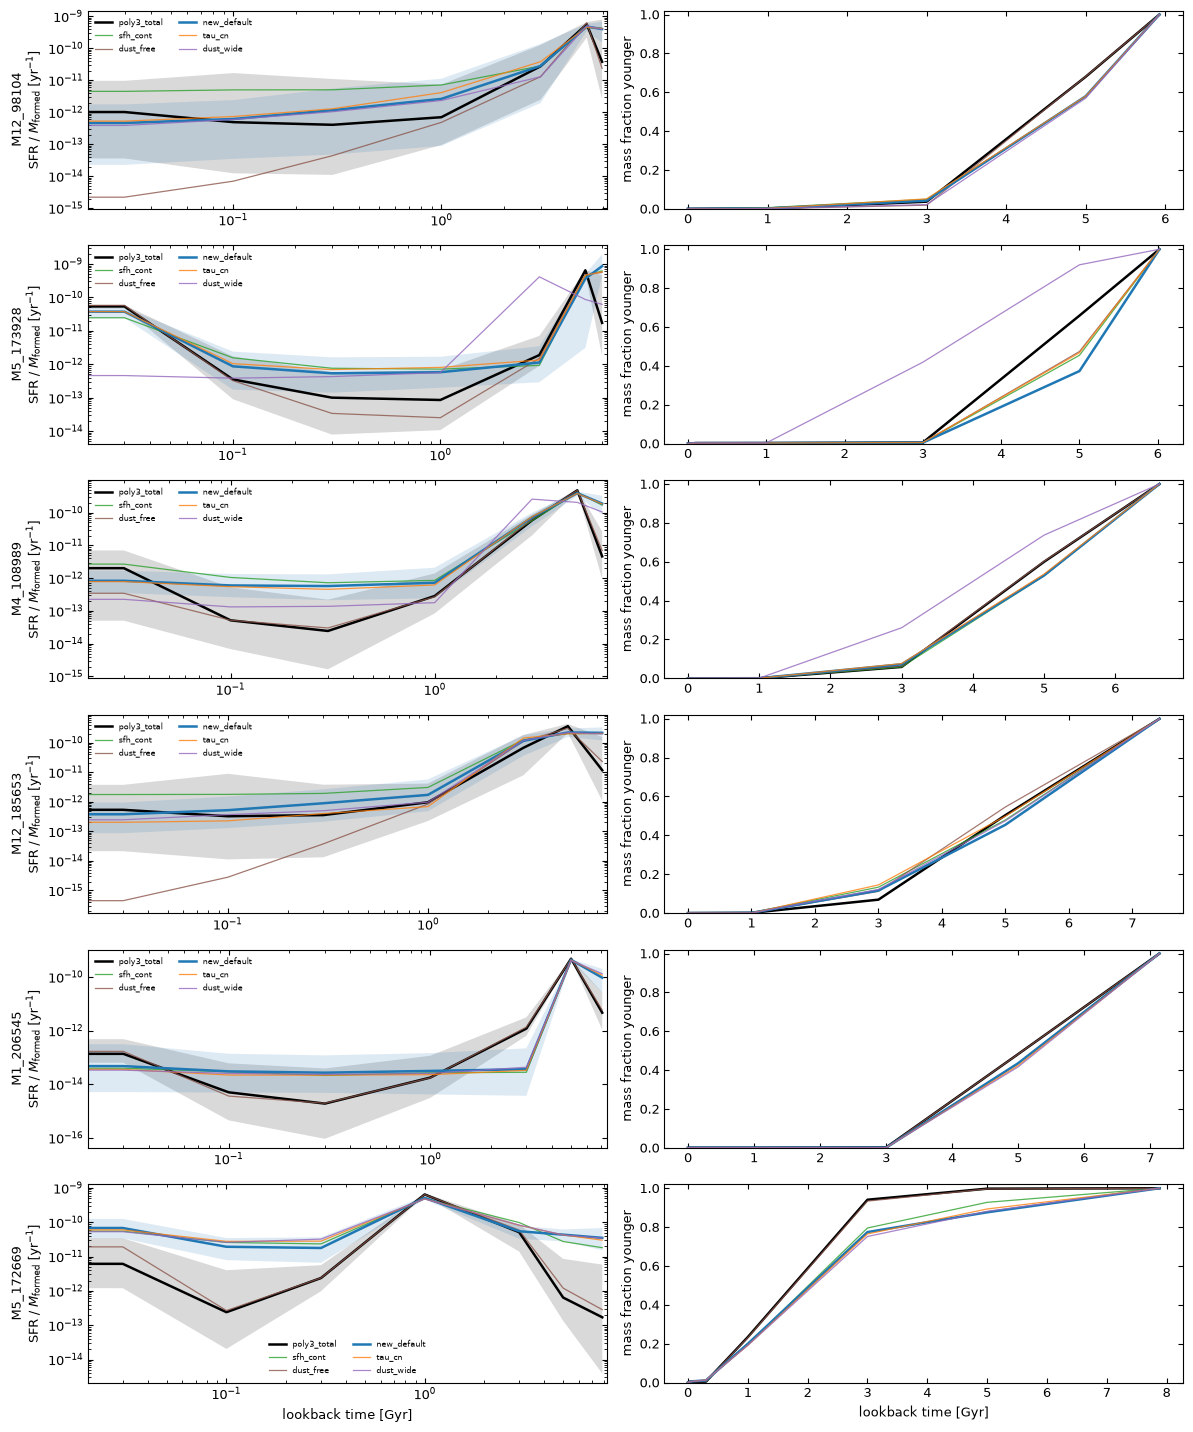

In [9]:
MAIN = [REF_ARM, NEW_ARM]
fig, axes = plt.subplots(len(galaxies), 2, figsize=(12, 2.4 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    for arm in [a for a in arms_present if a not in OLD_REPS + NEW_REPS]:
        if (arm, target) not in fits:
            continue
        sfh = fits[(arm, target)]["sfh"]; lb = sfh["lookback_time_gyr"]
        kw = dict(color=COLOURS[arm], lw=1.8 if arm in MAIN else 0.9, label=arm, alpha=1.0 if arm in MAIN else 0.8)
        axes[r, 0].plot(lb, sfh["normalized_sfr_q50"], **kw)
        if arm in MAIN:
            axes[r, 0].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=COLOURS[arm], alpha=0.15, lw=0)
        younger = np.concatenate([[0.0], np.cumsum(sfh["mass_fraction_q50"])])
        axes[r, 1].plot(lb, younger / younger[-1], **kw)
    axes[r, 0].set(xscale="log", yscale="log", ylabel=f"{target}\n" + r"SFR / $M_{\rm formed}$ [yr$^{-1}$]")
    axes[r, 0].set_xlim(0.02, lb[-1] * 1.05)
    axes[r, 1].set(ylabel="mass fraction younger", ylim=(0, 1.02))
    axes[r, 0].legend(frameon=False, fontsize=6, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("lookback time [Gyr]")
fig.tight_layout(); fig.savefig(RESULTS / "nd-sfh-histories.png", dpi=130); plt.show()

## Corner plots

- poly3_total against new_default and dust_wide; weighted dead points, 1-sigma contours of the 2-d mass.
- Mass-weighted age per sample with the notebook's trapezoid convention.

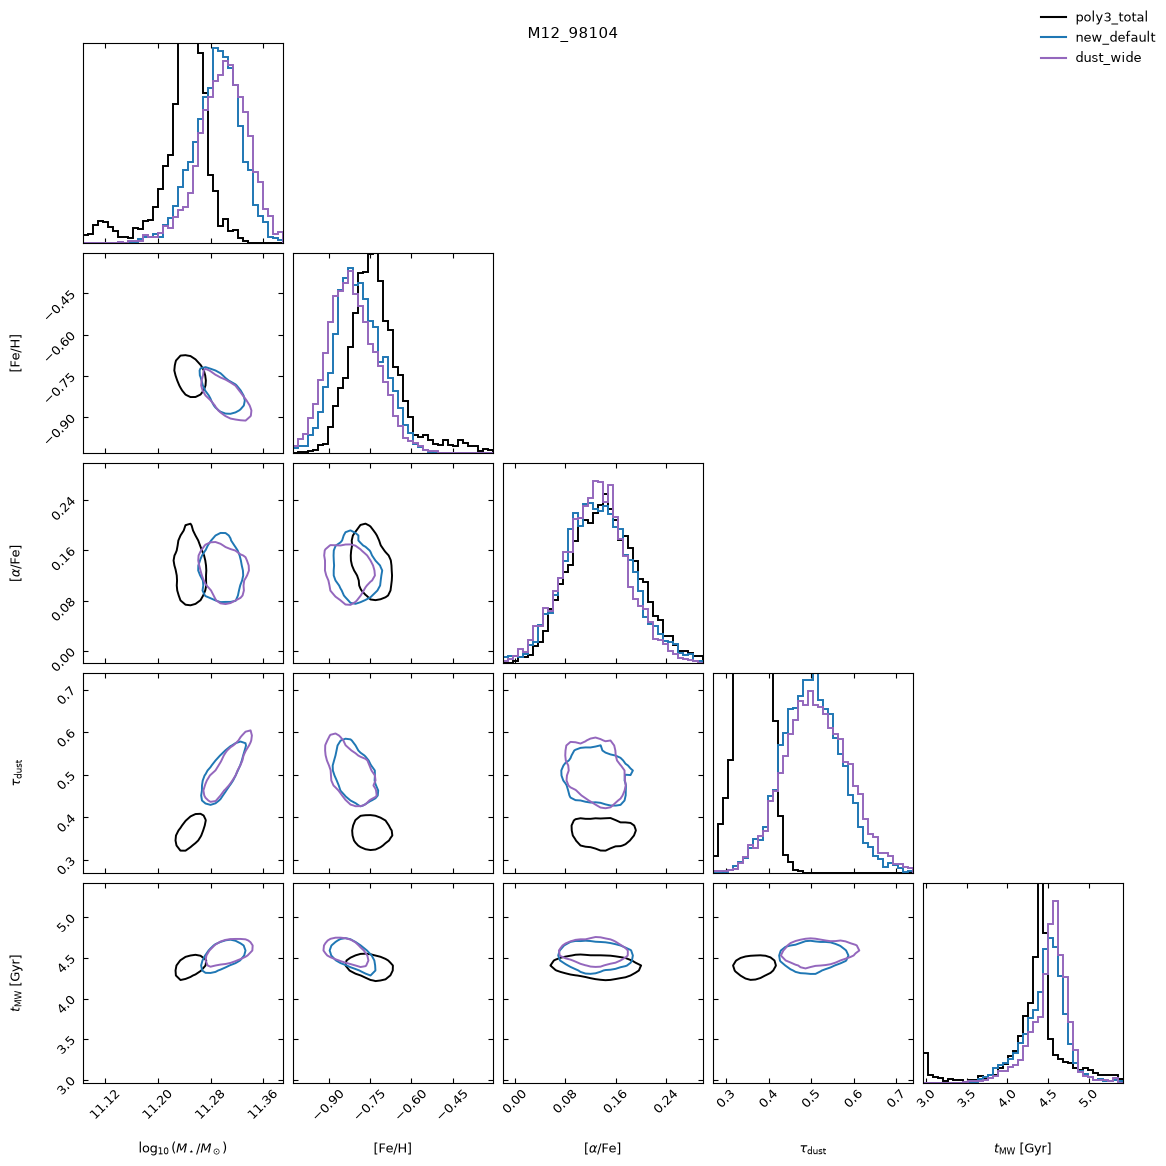

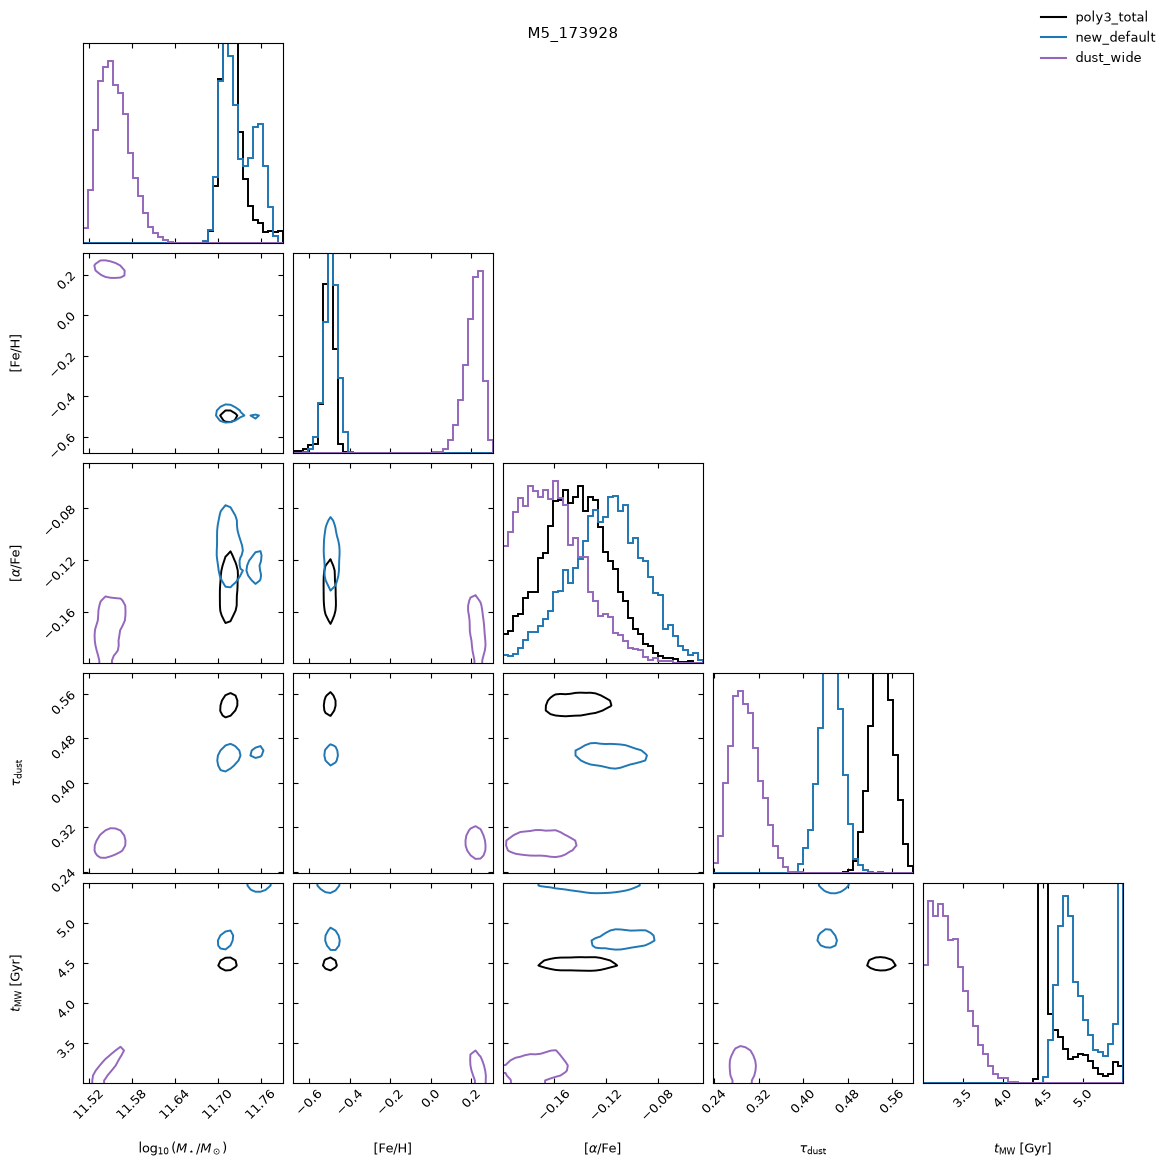

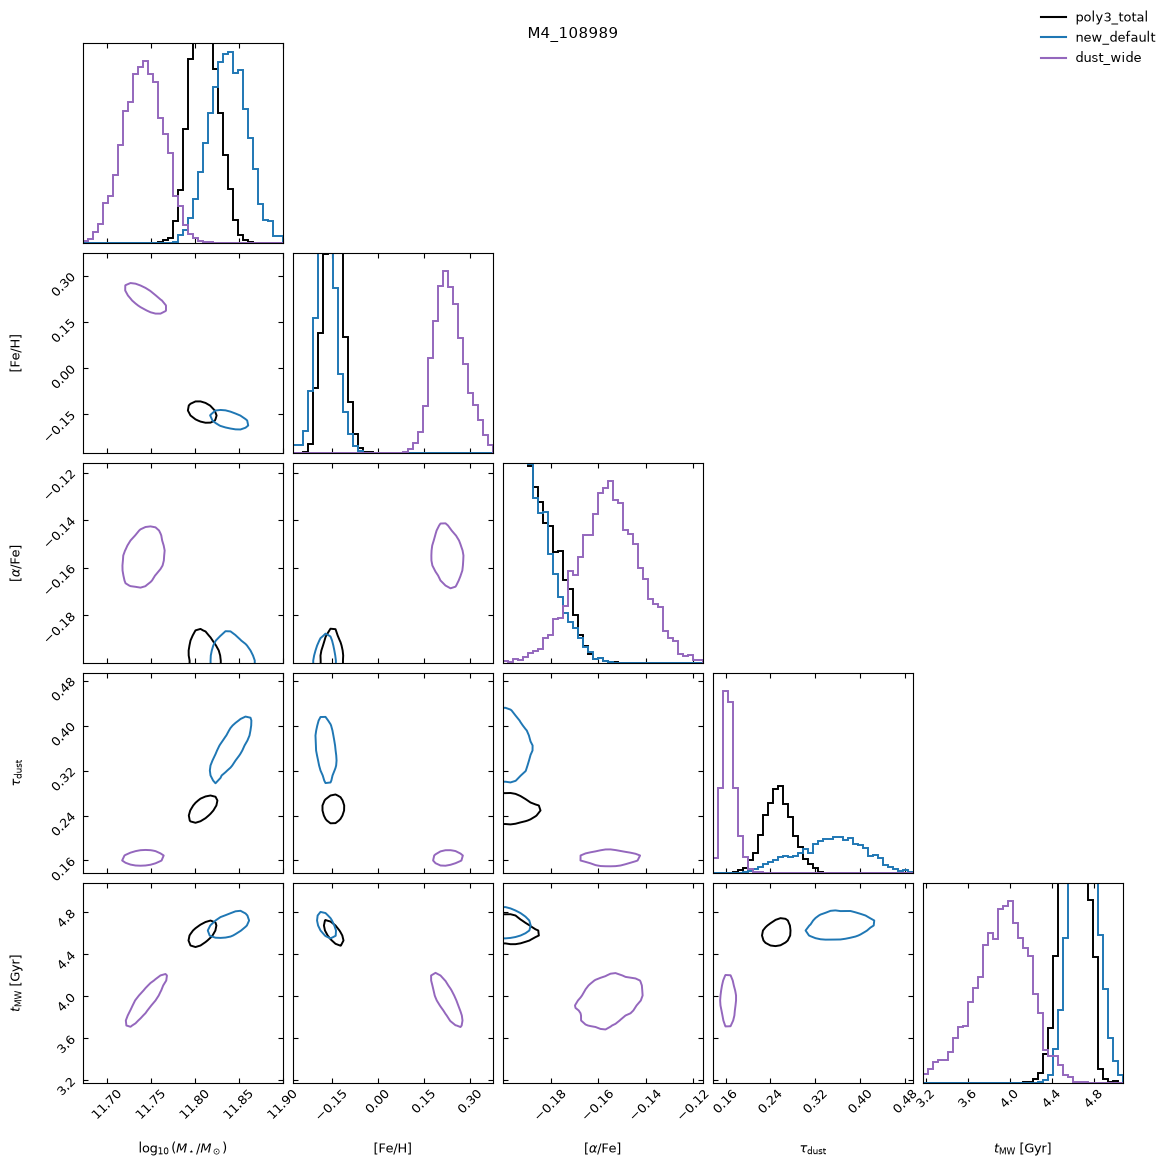

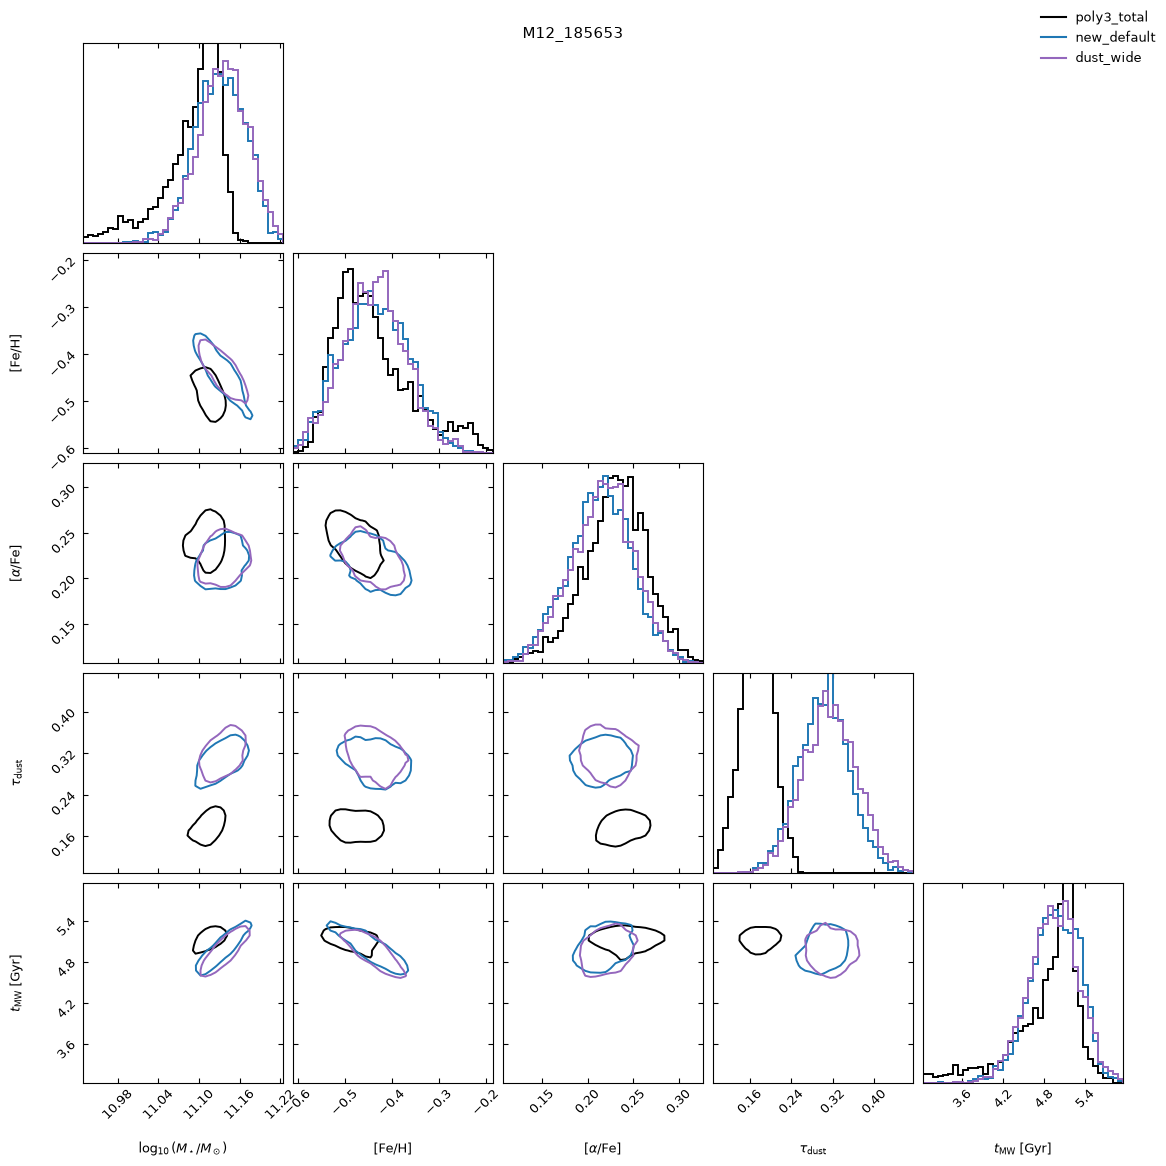

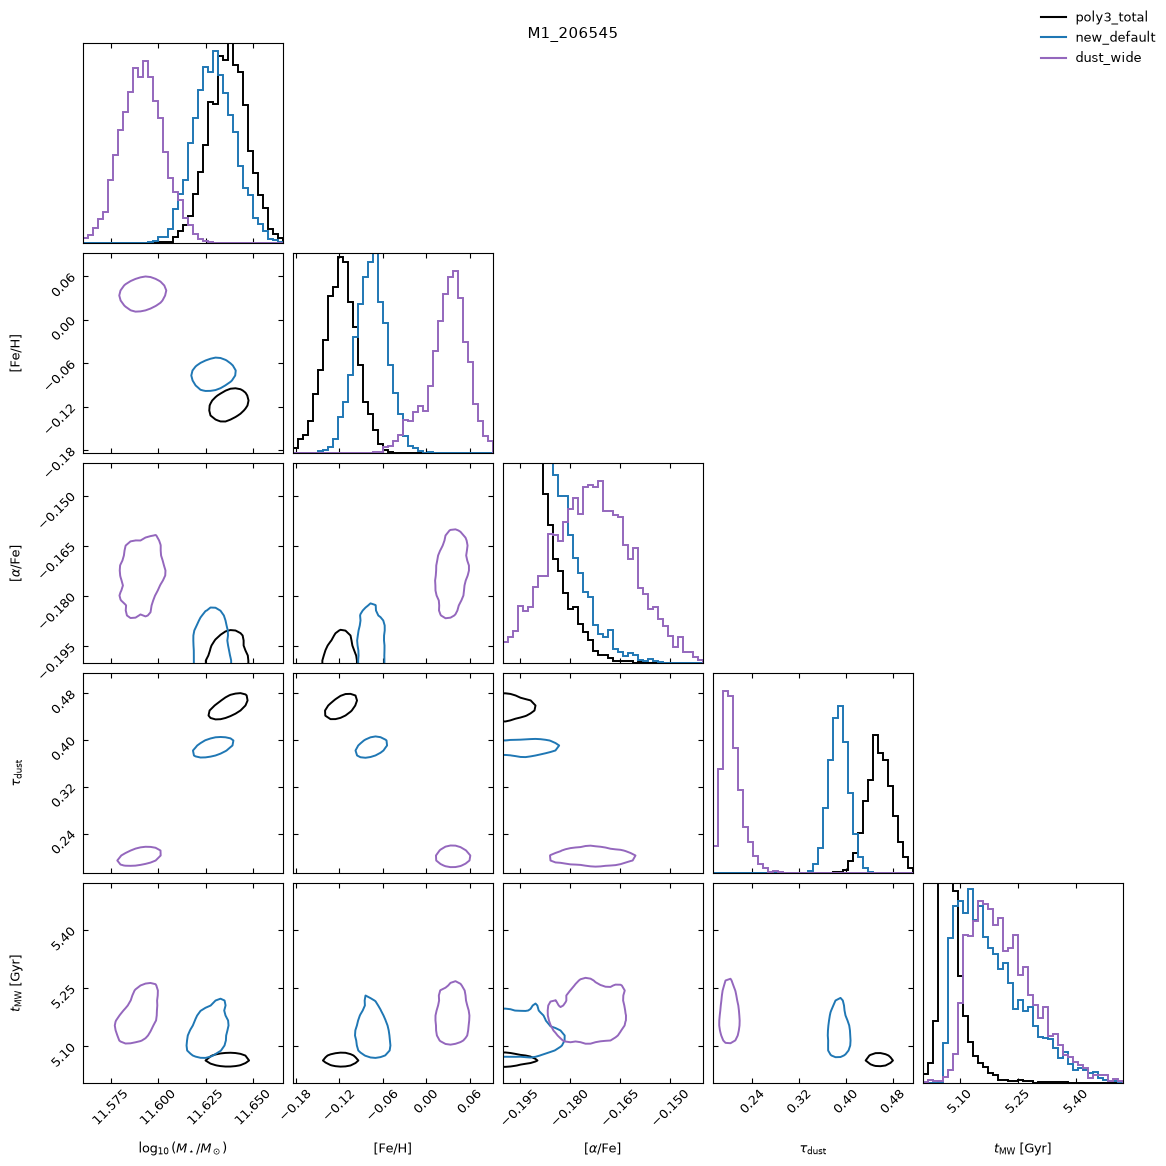

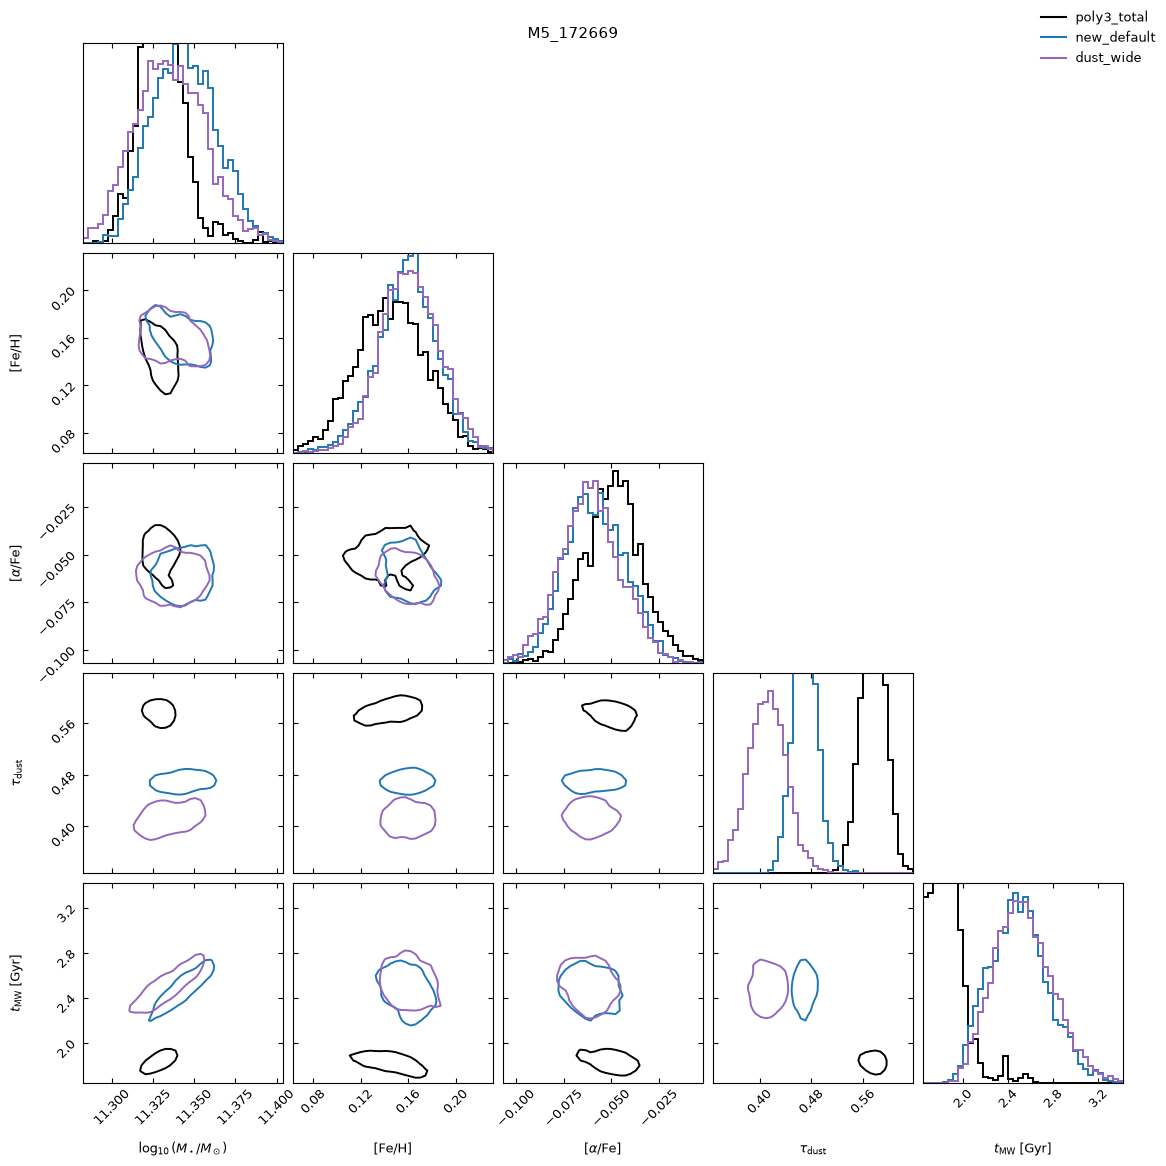

In [10]:
CORNER_ARMS = [a for a in [REF_ARM, NEW_ARM, "dust_wide"] if a in arms_present]
CORNER_LABELS = [LABELS[p] for p in ["logmass", "Z", "afe", "tau_dust", "age"]]


def corner_data(g):
    return np.column_stack([g.samples["logmass"], g.samples["Z"] + FEH_OFFSET, g.samples["afe"], g.samples["diffuse_tau_kc"], mw_age_samples(g)])


for target in galaxies:
    present = [a for a in CORNER_ARMS if (a, target) in fits]
    data = {a: (corner_data(fits[(a, target)]["galaxy"]), pgd.posterior_weights(fits[(a, target)]["galaxy"])) for a in present}
    lo = np.min([[pgd.weighted_quantile(x[:, k], w, 0.002) for k in range(5)] for x, w in data.values()], axis=0)
    hi = np.max([[pgd.weighted_quantile(x[:, k], w, 0.998) for k in range(5)] for x, w in data.values()], axis=0)
    rng_ = [(a, b) if b > a else (a - 1e-3, a + 1e-3) for a, b in zip(lo, hi)]
    fig = None
    for a in present:
        x, w = data[a]
        fig = corner.corner(x, weights=w, labels=CORNER_LABELS, range=rng_, color=COLOURS[a], fig=fig, bins=40, smooth=1.0,
                            plot_datapoints=False, plot_density=False, fill_contours=False, levels=[1 - np.exp(-0.5)],
                            hist_kwargs=dict(density=True, lw=1.4), contour_kwargs=dict(linewidths=1.4))
    fig.legend(handles=[plt.Line2D([], [], color=COLOURS[a], label=a) for a in present], loc="upper right", frameon=False, fontsize=9)
    fig.suptitle(target, y=0.98)
    fig.savefig(RESULTS / f"nd-corner-{target}.png", dpi=110); plt.show()

## Fit plots for new_default

- Top: LEGA-C spectrum with the poly3_total and new_default median models; grey bands are excluded pixels.
- Second: new_default pull at f_calib = 3%. Third: photometry, observed against both models, pulls in the inset text.
- Bottom: cumulative (arm - poly3_total) chi2 at f_calib = 3% for new_default, tau_cn, dust_wide.

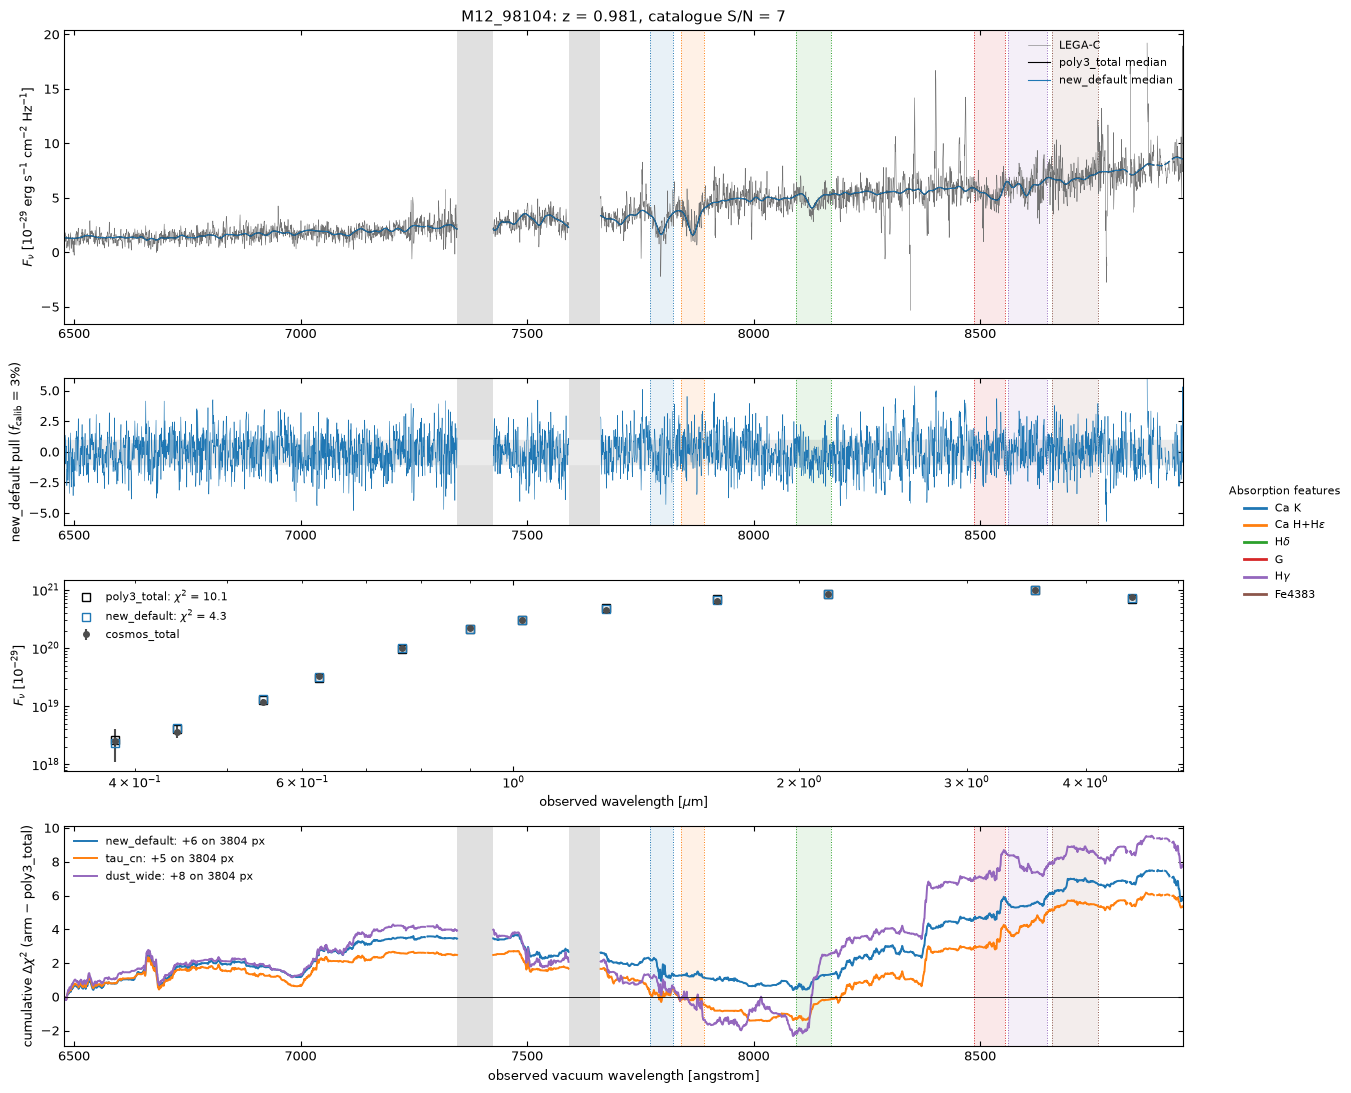

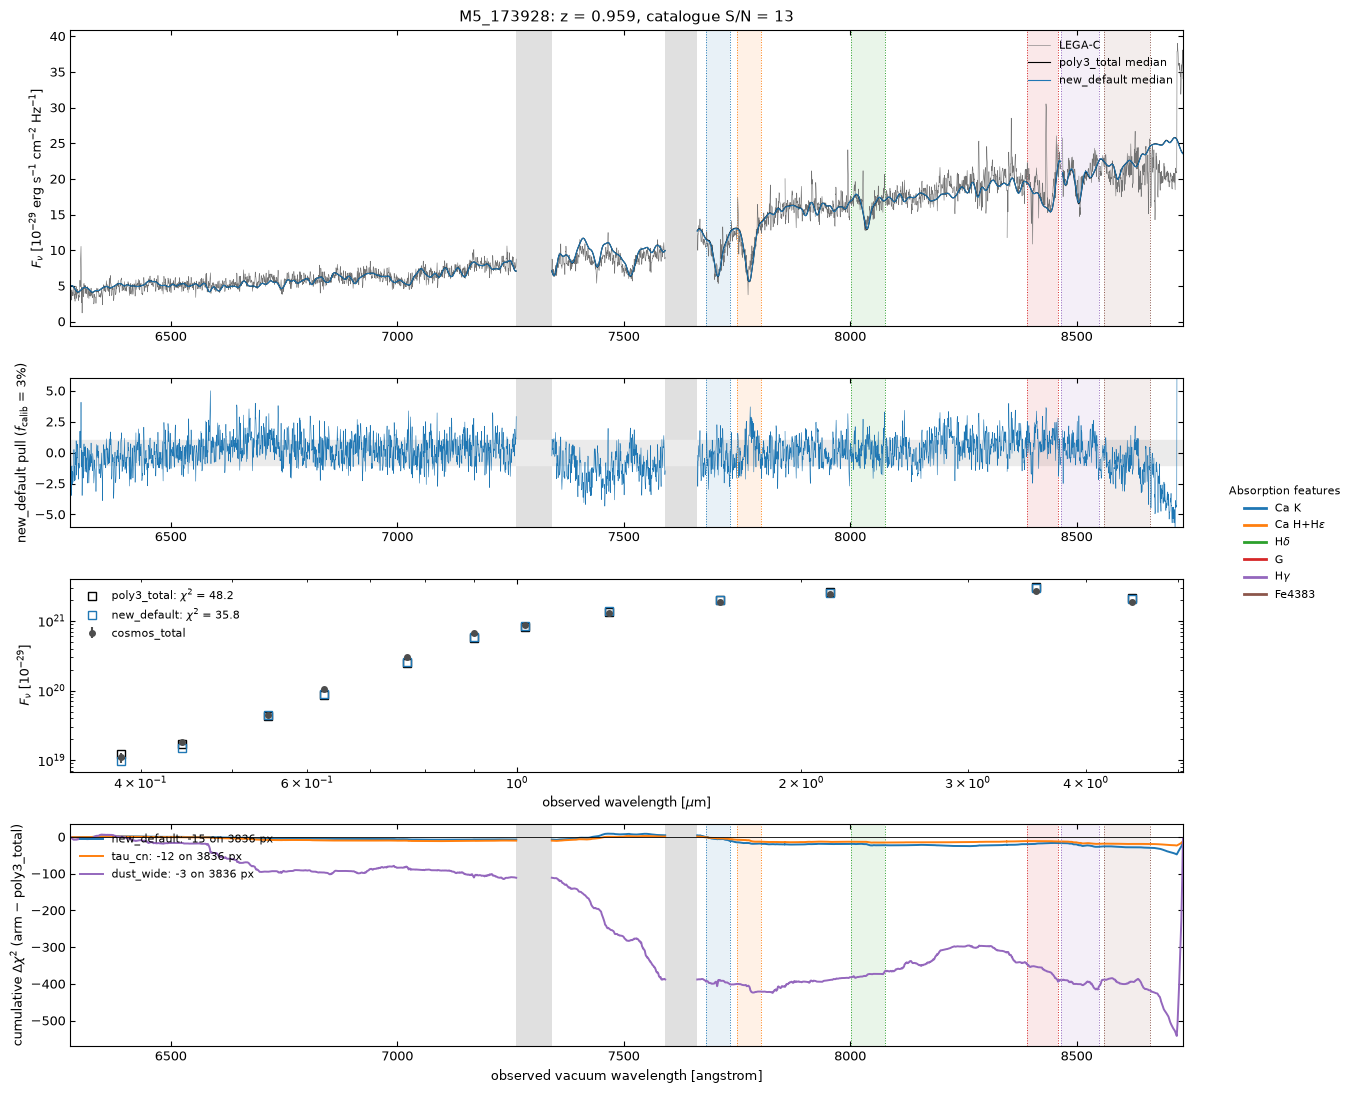

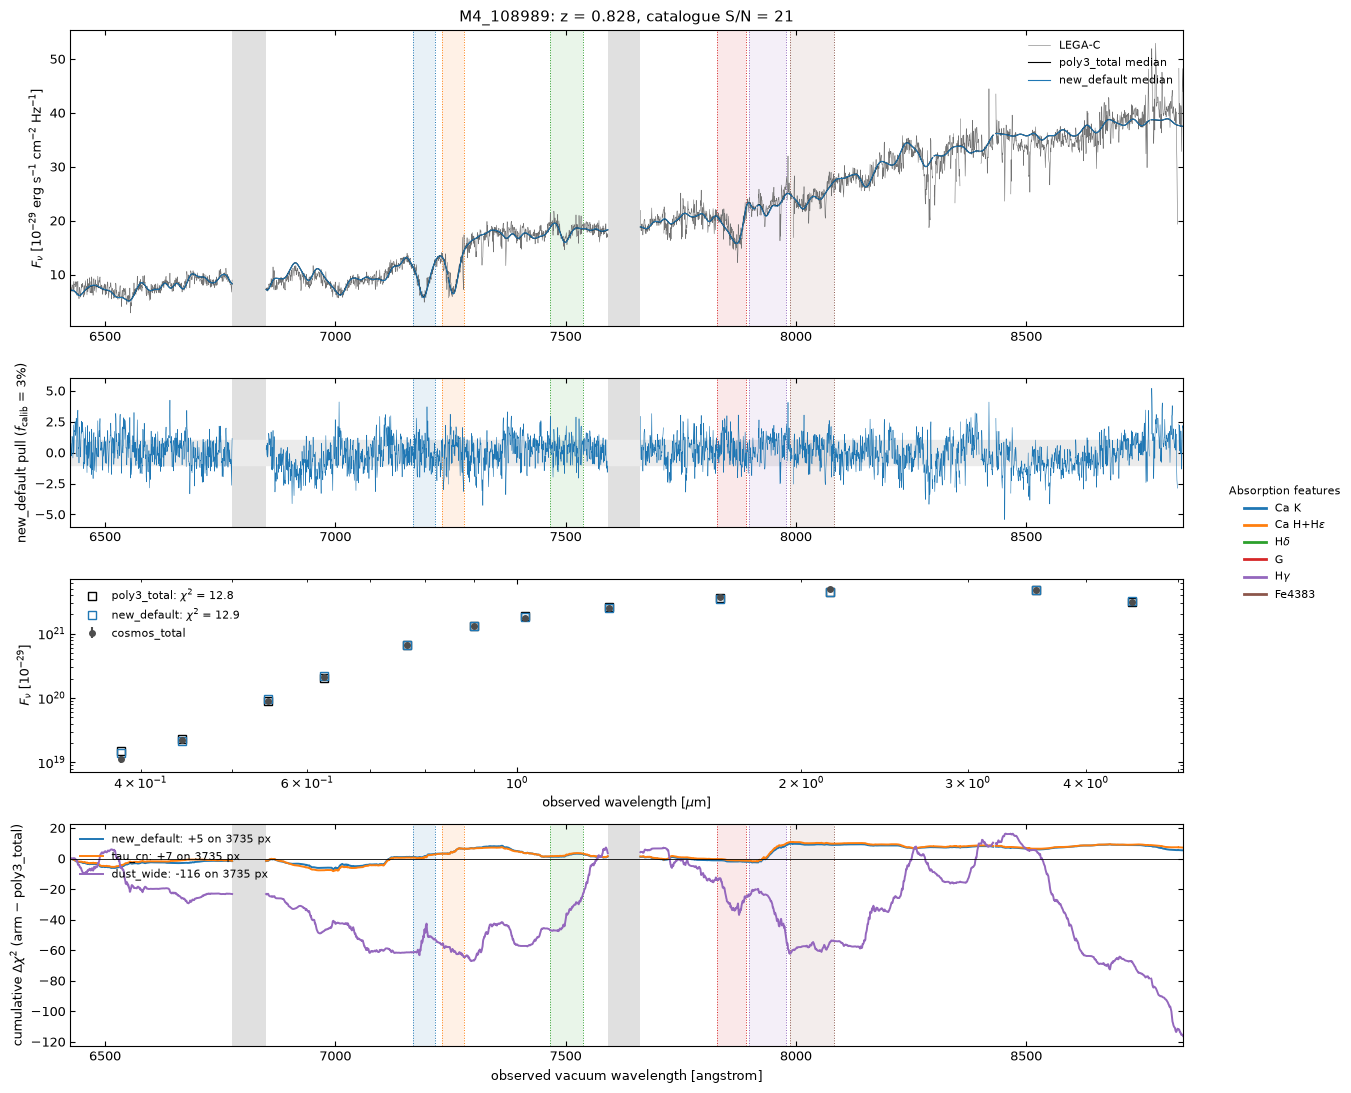

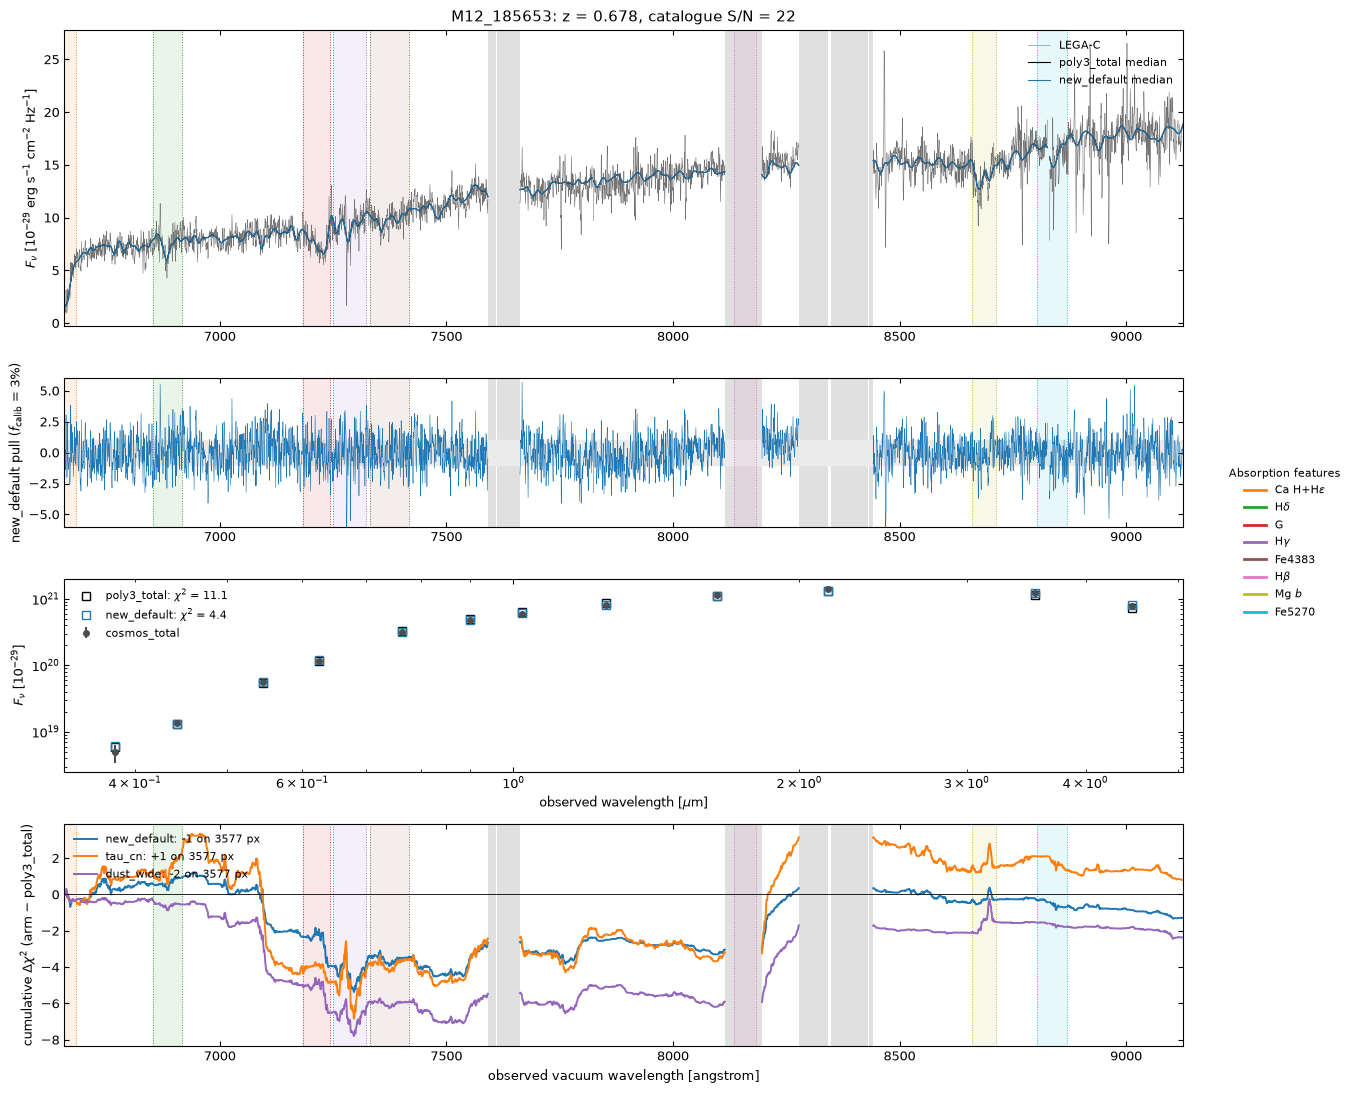

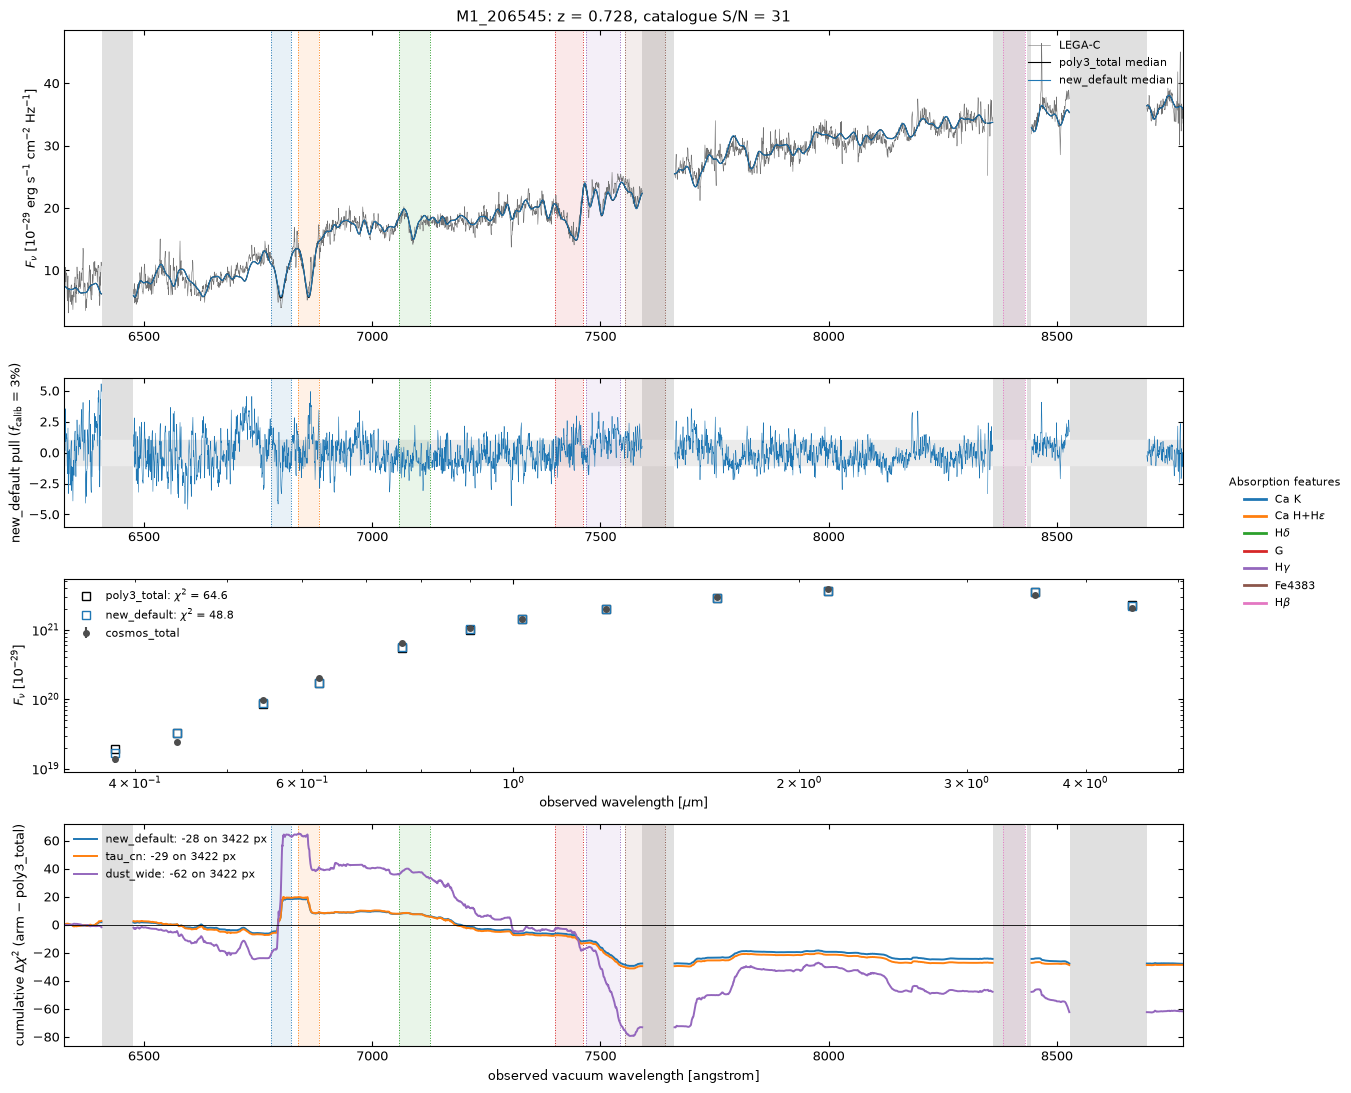

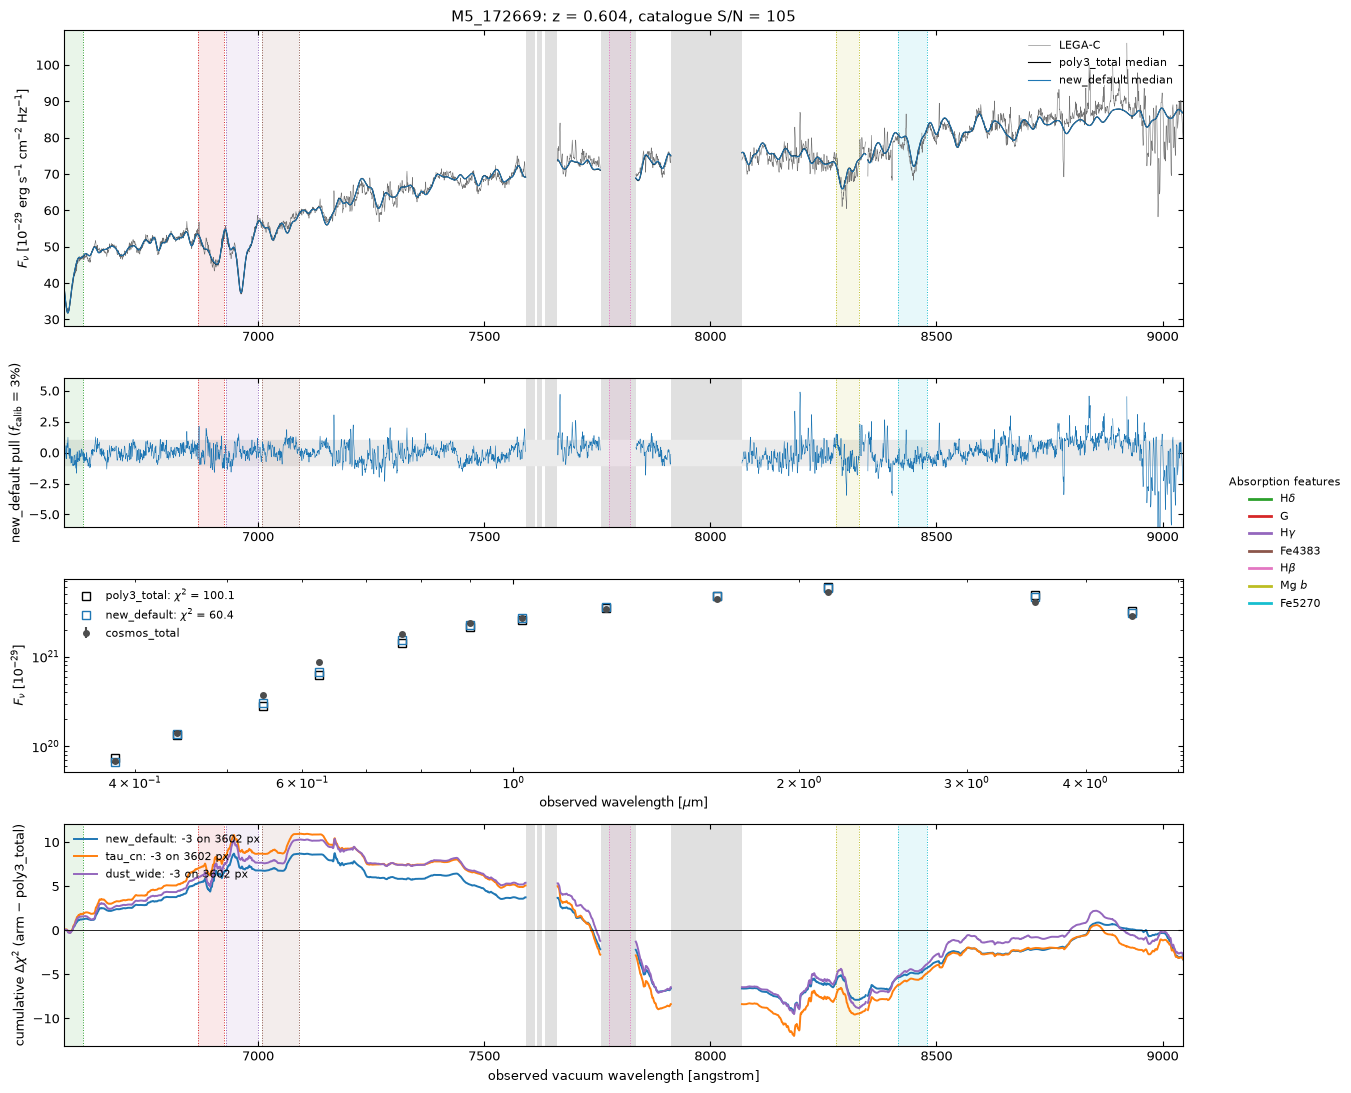

In [11]:
def _runs(wave, flag):
    edges = np.flatnonzero(np.diff(np.concatenate([[0], flag.astype(int), [0]])))
    return [(wave[s], wave[min(e, wave.size) - 1]) for s, e in zip(edges[::2], edges[1::2])]


def chi_at_f(fit, f_pct):
    s = fit["spectrum"]
    sigma = np.hypot(s["uncertainty"], (f_pct / 100.0) * np.abs(s["posterior_q50"]))
    return (s["observed"] - s["posterior_q50"]) / sigma


def fit_figure(target):
    ref, new = fits[(REF_ARM, target)], fits[(NEW_ARM, target)]
    s = ref["spectrum"]; wave = s["wavelength"]; rmask = s["mask"].astype(bool)
    excluded = (s["uncertainty"] < 1.0) & ~rmask
    fig, axes = plt.subplots(4, 1, figsize=(12, 11), gridspec_kw={"height_ratios": [2, 1, 1.3, 1.5]})
    for ax in (axes[0], axes[1], axes[3]):
        for lo, hi in _runs(wave, excluded):
            ax.axvspan(lo, hi, color="0.88", lw=0, zorder=0)
    scale = 1e29
    axes[0].plot(wave, np.where(rmask, s["observed"] * scale, np.nan), color="0.45", lw=0.4, label="LEGA-C")
    for arm, fit in ((REF_ARM, ref), (NEW_ARM, new)):
        axes[0].plot(wave, np.where(rmask, fit["spectrum"]["posterior_q50"] * scale, np.nan), color=COLOURS[arm], lw=0.8, label=f"{arm} median")
    axes[0].set_ylabel(r"$F_\nu$ [$10^{-29}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    axes[0].set_title(f"{target}: z = {ref['attrs']['redshift']:.3f}, catalogue S/N = {ref['attrs']['catalogue_sn']:.0f}")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right")
    axes[1].plot(wave, np.where(rmask, chi_at_f(new, F_FIXED_PCT), np.nan), color=COLOURS[NEW_ARM], lw=0.4)
    axes[1].axhspan(-1, 1, color="0.92", zorder=0); axes[1].set_ylim(-6, 6); axes[1].set_ylabel(r"new_default pull ($f_{\rm calib}$ = 3%)")
    for ax in axes[:2]:
        ax.set_xlim(wave[rmask].min(), wave[rmask].max())
    p = ref["photometry"]; pm = p["mask"].astype(bool); lam = p["wavelength"] / 1e4
    axes[2].errorbar(lam[pm], p["observed"][pm] * scale, yerr=p["uncertainty"][pm] * scale, fmt="o", color="0.3", ms=4, label="cosmos_total")
    for arm, fit in ((REF_ARM, ref), (NEW_ARM, new)):
        q = fit["photometry"]
        axes[2].plot(lam[pm], q["posterior_q50"][pm] * scale, "s", mfc="none", color=COLOURS[arm], ms=6,
                     label=rf"{arm}: $\chi^2$ = {np.sum(q['pull'][pm] ** 2):.1f}")
    axes[2].set(xscale="log", yscale="log", xlabel=r"observed wavelength [$\mu$m]", ylabel=r"$F_\nu$ [$10^{-29}$]")
    axes[2].legend(frameon=False, fontsize=8)
    chi_ref = chi_at_f(ref, F_FIXED_PCT)
    for arm in [NEW_ARM] + EXTRA:
        if (arm, target) not in fits:
            continue
        fit = fits[(arm, target)]
        dchi2 = np.where(rmask, chi_at_f(fit, F_FIXED_PCT) ** 2 - chi_ref ** 2, 0.0)
        axes[3].plot(wave, np.where(rmask, np.cumsum(dchi2), np.nan), color=COLOURS[arm], lw=1.4, label=f"{arm}: {dchi2.sum():+.0f} on {rmask.sum()} px")
    axes[3].axhline(0, color="k", lw=0.6); axes[3].set_xlim(wave[rmask].min(), wave[rmask].max())
    axes[3].set_ylabel(r"cumulative $\Delta\chi^2$ (arm $-$ poly3_total)")
    for ax in axes[:2]:                                   # axes[2] is the SED in micron
        mark_absorption_features(ax, ref["attrs"]["redshift"], show_labels=False)
    mark_absorption_features(axes[3], ref["attrs"]["redshift"],
                             xlabel="observed vacuum wavelength [angstrom]")
    axes[3].legend(frameon=False, fontsize=8, loc="upper left")
    spectral_tight_layout(fig); fig.savefig(RESULTS / f"nd-fit-{target}.png", dpi=130); plt.show()


for target in galaxies:
    if (NEW_ARM, target) in fits:
        fit_figure(target)

## Lick indices per arm

- Every fit rebuilt on CPU with `StellarIndices` riding along; 200 weighted posterior draws.
- Residual = (model q50 - catalogue) / sqrt(catalogue err^2 + posterior half-width^2). Catalogue indices come from uncalibrated DR2 spectra; sanity check only.
- `lnL rebuilt/stored - 1` checks the rebuild reproduces each arm's likelihood.

In [12]:
INDEX_MAP = {"CN1": "LICK_CN1", "CN2": "LICK_CN2", "Ca4227": "LICK_CA4227", "G4300": "LICK_G4300", "Fe4383": "LICK_FE4383",
             "Ca4455": "LICK_CA4455", "Fe4531": "LICK_FE4531", "C4668": "LICK_C4668", "Hbeta": "LICK_HB", "HdA": "LICK_HD_A",
             "HgA": "LICK_HG_A", "HdF": "LICK_HD_F", "HgF": "LICK_HG_F", "Dn4000": "LICK_D4000_N"}
KEY_INDICES = ["HdA", "HdF", "Fe4383", "Dn4000", "Hbeta", "CN1", "C4668"]
cat = Table.read(PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz").to_pandas()
cat["SPECT_ID"] = cat["SPECT_ID"].astype(str).str.strip()
cat = cat.set_index("SPECT_ID").loc[galaxies]
N_DRAWS = 200
rng = np.random.default_rng(20260906)
ssp = pgd.load_ssp()
lick_rows, rebuild_rows = [], []
t0 = time.time()
for (arm, target), fit in sorted(fits.items()):
    if arm not in arms_present:
        continue
    g = fit["galaxy"]
    indices_obs = StellarIndices(definitions=LEGAC_DR2_STELLAR_INDEX_DEFINITIONS, resolution=g.spec["resolution"], smoothtype=g.spec["smoothtype"],
                                 res_convention=pgd.RES_CONVENTION, sigma_losvd=g.sigma_star_kms, name="stellar_indices")
    model, likelihood, _ = pgd.rebuild_model(g, ssp, extra_observations=(indices_obs,))
    k = pgd.max_likelihood_index(g)
    rebuild_rows.append({"arm": arm, "target": target, "lnL rebuilt/stored - 1": pgd.likelihood_terms(model, likelihood, pgd.theta_at(g, k))["lnl"] / g.log_likelihoods[k] - 1})
    w = pgd.posterior_weights(g)
    draws = rng.choice(len(w), size=N_DRAWS, replace=True, p=w)
    predict = jax.jit(lambda th: model.predict(th)["stellar_indices"])
    vals = np.array([np.asarray(predict(pgd.theta_at(g, j))) for j in draws])
    q16, q50, q84 = np.percentile(vals, [16, 50, 84], axis=0)
    for i, name in enumerate(indices_obs.index_names):
        obs, err = float(cat.loc[target, INDEX_MAP[name]]), float(cat.loc[target, INDEX_MAP[name] + "_err"])
        if not np.isfinite(err) or err <= 0:
            obs = np.nan
        lick_rows.append({"arm": arm, "target": target, "index": name, "catalogue": obs, "cat err": err, "model q50": q50[i],
                          "model hw": 0.5 * (q84[i] - q16[i]), "resid": (q50[i] - obs) / np.hypot(err, 0.5 * (q84[i] - q16[i]))})
print(f"{len(rebuild_rows)} fits rebuilt in {time.time() - t0:.0f} s")
lick = pd.DataFrame(lick_rows)
rebuild = pd.DataFrame(rebuild_rows).set_index(["target", "arm"]).sort_index()
assert rebuild["lnL rebuilt/stored - 1"].abs().max() < 1e-2, rebuild
rebuild.unstack("arm").round(5)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 4% of pixels over [5248, 5945] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


...

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


46 fits rebuilt in 42 s


lnL rebuilt/stored - 1                                                                                                                  
arm                     dust_free dust_wide new_default new_default_rep1 new_default_rep2 poly3_total seed_rep1 seed_rep2 seed_rep3 sfh_cont tau_cn
target                                                                                                                                             
M12_185653                   -0.0      -0.0        -0.0              NaN              NaN        -0.0       NaN       NaN       NaN     -0.0   -0.0
M12_98104                    -0.0      -0.0        -0.0              NaN              NaN        -0.0       NaN       NaN       NaN     -0.0   -0.0
M1_206545                    -0.0      -0.0        -0.0              NaN              NaN        -0.0       NaN       NaN       NaN     -0.0   -0.0
M4_108989                    -0.0      -0.0        -0.0             -0.0             -0.0        -0.0      -0.0      -0.0      -0.0     -0.0   -0.0
M5_172669                     0.0       0.0         0.0              0.0              0.0         0.0       0.0       0.0       0.0      0.0    0.0
M5_173928                    -0.0      -0.0        -0.0              NaN              NaN         0.0       NaN       NaN       NaN      0.0   -0.0

In [13]:
key = lick[lick["index"].isin(KEY_INDICES)]
lick_abs = key.groupby(["arm", "target"])["resid"].apply(lambda s: s.abs().mean()).unstack("target")
lick_abs = lick_abs.reindex([a for a in arms_present if a in lick_abs.index])
lick_abs["mean"] = lick_abs[galaxies].mean(axis=1)
lick_abs["vs poly3_total"] = (lick_abs[galaxies] - lick_abs.loc[REF_ARM, galaxies]).mean(axis=1)
if NEW_ARM in lick_abs.index:
    lick_abs["vs new_default"] = (lick_abs[galaxies] - lick_abs.loc[NEW_ARM, galaxies]).mean(axis=1)
lick_abs.to_csv(RESULTS / "lick-new-defaults.csv")
lick_abs

target,M12_185653,M12_98104,M1_206545,M4_108989,M5_172669,M5_173928,mean,vs poly3_total,vs new_default
arm,,,,,,,,,
poly3_total,2.457,1.033,2.234,3.435,1.892,2.839,2.315,0.000,0.002
seed_rep1,NaN,NaN,NaN,3.454,1.981,NaN,2.718,0.054,-0.032
seed_rep2,NaN,NaN,NaN,3.455,1.978,NaN,2.716,0.053,-0.034
seed_rep3,NaN,NaN,NaN,3.426,2.001,NaN,2.713,0.050,-0.037
sfh_cont,2.401,0.970,2.234,3.424,1.878,2.731,2.273,-0.042,-0.040
dust_free,2.403,1.280,2.211,3.601,1.881,2.756,2.355,0.040,0.042
new_default,2.447,1.101,2.218,3.615,1.885,2.612,2.313,-0.002,0.000
new_default_rep1,NaN,NaN,NaN,3.589,1.896,NaN,2.743,0.079,-0.007
new_default_rep2,NaN,NaN,NaN,3.650,1.780,NaN,2.715,0.051,-0.035


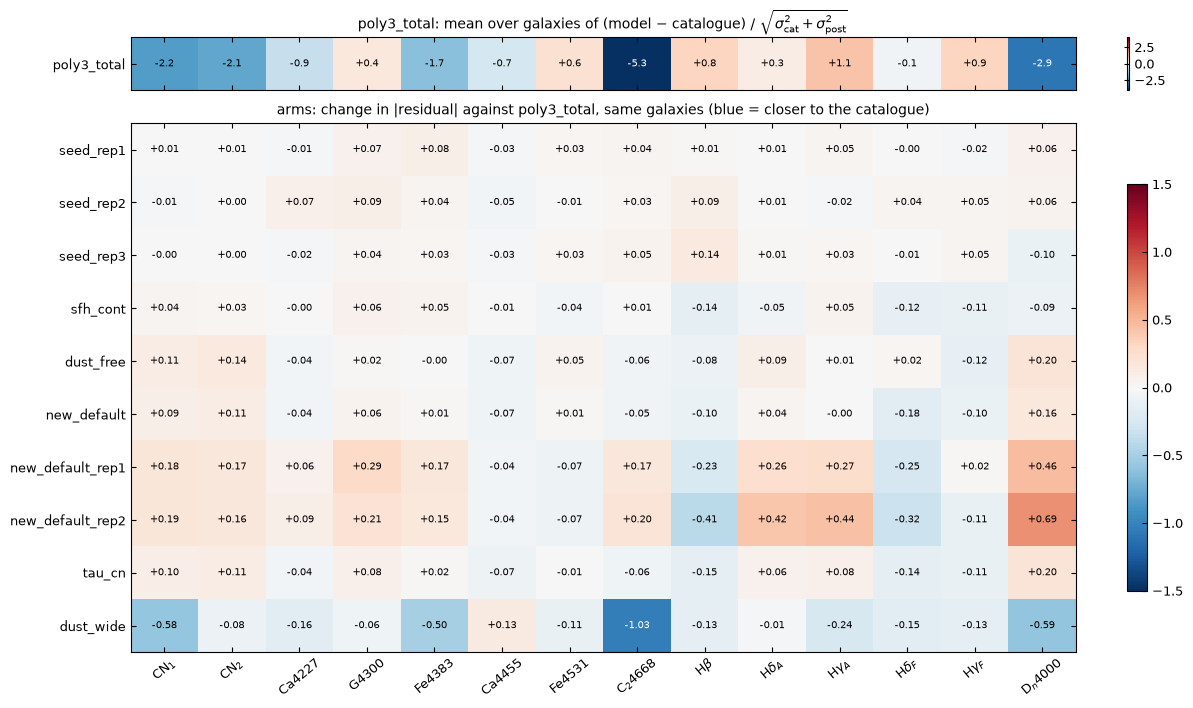

In [14]:
INDEX_LABELS = {"CN1": r"CN$_1$", "CN2": r"CN$_2$", "Ca4227": "Ca4227", "G4300": "G4300", "Fe4383": "Fe4383", "Ca4455": "Ca4455",
                "Fe4531": "Fe4531", "C4668": r"C$_2$4668", "Hbeta": r"H$\beta$", "HdA": r"H$\delta_A$", "HgA": r"H$\gamma_A$",
                "HdF": r"H$\delta_F$", "HgF": r"H$\gamma_F$", "Dn4000": r"D$_n$4000"}
resid = lick.set_index(["arm", "target", "index"])["resid"]
ref_resid = resid.xs(REF_ARM, level="arm")
signed_ref = ref_resid.groupby("index").mean().reindex(list(INDEX_MAP))
arm_rows = [a for a in arms_present if a != REF_ARM and a in lick["arm"].unique()]
delta_abs = pd.DataFrame({a: (resid.xs(a, level="arm").abs() - ref_resid.abs().reindex(resid.xs(a, level="arm").index)).groupby("index").mean()
                          for a in arm_rows}).T.reindex(columns=list(INDEX_MAP))
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 0.45 * (len(arm_rows) + 1) + 2.2), gridspec_kw={"height_ratios": [1, max(len(arm_rows), 1)]}, sharex=True)
im0 = ax0.imshow(signed_ref.to_numpy()[None, :], aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4)
ax0.set_yticks([0]); ax0.set_yticklabels([REF_ARM])
for j, v in enumerate(signed_ref.to_numpy()):
    ax0.text(j, 0, f"{v:+.1f}", ha="center", va="center", fontsize=7, color="k" if abs(v) < 2.5 else "w")
ax0.set_title(r"poly3_total: mean over galaxies of (model $-$ catalogue) / $\sqrt{\sigma_{\rm cat}^2+\sigma_{\rm post}^2}$", fontsize=10)
im1 = ax1.imshow(delta_abs.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
ax1.set_yticks(range(len(arm_rows))); ax1.set_yticklabels(arm_rows)
for i in range(delta_abs.shape[0]):
    for j in range(delta_abs.shape[1]):
        v = delta_abs.to_numpy()[i, j]
        if np.isfinite(v):
            ax1.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7, color="k" if abs(v) < 1.0 else "w")
ax1.set_xticks(range(len(INDEX_MAP))); ax1.set_xticklabels([INDEX_LABELS[k] for k in INDEX_MAP], rotation=40)
ax1.set_title(r"arms: change in $|$residual$|$ against poly3_total, same galaxies (blue = closer to the catalogue)", fontsize=10)
fig.colorbar(im0, ax=ax0, fraction=0.02); fig.colorbar(im1, ax=ax1, fraction=0.02)
fig.tight_layout(); fig.savefig(RESULTS / "nd-lick.png", dpi=130); plt.show()

## Borghi+22 overlap per arm

- M4_108989 and M12_185653; Borghi ages are SSP-equivalent, ours mass-weighted. Sanity check only.
- Tension = (ours - Borghi) / sqrt(our half-width^2 + Borghi err^2); [Fe/H] = grid Z + 1.7328 (Z_sun = 0.0185); Borghi tabulates [Z/H].

In [15]:
borghi = pd.concat([pd.read_csv(p, sep="\t", comment="#") for p in (PROJECT_ROOT / "data/processed/borghi2022_legac_dr2").glob("*_spectrum_matches.tsv")]).set_index("dr2_spect_id")
brows = []
for (arm, target), fit in sorted(fits.items()):
    if target not in borghi.index or arm not in arms_present:
        continue
    b, row = borghi.loc[target], table.loc[(target, arm)]
    for ours, hw, ref_val, ref_err, name in [
            (row["age_q50"], row["age_hw"], b["borghi_age_gyr"], 0.5 * (b["borghi_age_err_lower_gyr"] + b["borghi_age_err_upper_gyr"]), "age [Gyr]"),
            (row["Z_q50"], row["Z_hw"], b["borghi_z_over_h_dex"], b["borghi_z_over_h_err_upper_dex"], "[Fe/H] vs [Z/H]"),
            (row["afe_q50"], row["afe_hw"], b["borghi_alpha_over_fe_dex"], b["borghi_alpha_over_fe_err_upper_dex"], "[a/Fe]")]:
        brows.append({"target": target, "arm": arm, "quantity": name, "ours": ours, "ours hw": hw, "Borghi": ref_val, "Borghi err": ref_err,
                      "tension": (ours - ref_val) / np.hypot(hw, ref_err)})
borghi_table = pd.DataFrame(brows)
borghi_table.to_csv(RESULTS / "borghi-new-defaults.csv", index=False)
borghi_table.pivot(index=["target", "arm"], columns="quantity", values="tension").reindex(
    [(t, a) for t in galaxies for a in arms_present if (t, a) in table.index and t in borghi.index])

quantity                     [Fe/H] vs [Z/H]  [a/Fe]  age [Gyr]
target     arm                                                 
M4_108989  poly3_total                -2.933  -5.190      0.949
           seed_rep1                  -2.945  -5.233      0.943
           seed_rep2                  -2.938  -5.201      0.968
           seed_rep3                  -3.012  -5.204      0.961
           sfh_cont                   -2.989  -5.182      1.175
           dust_free                  -3.338  -5.322      0.927
           new_default                -3.231  -5.273      1.097
           new_default_rep1           -3.338  -5.292      1.039
           new_default_rep2           -3.349  -5.264      1.031
           tau_cn                     -3.302  -5.280      1.089
           dust_wide                   1.935  -4.404     -0.108
M12_185653 poly3_total                -4.810   4.041      3.460
           sfh_cont                   -4.487   3.907      3.033
           dust_free                  -4.329   3.613      2.886
           new_default                -5.078   3.769      3.575
           tau_cn                     -5.234   3.730      3.210
           dust_wide                  -5.246   3.882      3.300

## Mock: both flips on the 4 percent tilt mock

- Same mock (M5_172669 truth, tilt 0.04, seed 1, cosmos_ap3) under the original model, the continuity prior alone, and both flips.
- Pull = (median - truth) / half width. Caveat: the truth SFH was drawn from a flat-prior fit, so it is spiky and favours the uniform prior.
- `mock_tilt4_new_default` did not run: the stored truth has no `diffuse_dust_index`, so the free-index mock check aborted before sampling.

truth dust index: -0.7


,logmass,Z,afe,tau_dust,age,logmass_hw,Z_hw,afe_hw,tau_dust_hw,age_hw
arm,,,,,,,,,,
mock_tilt4_poly3,1.38,-0.68,-0.03,0.71,0.64,0.01,0.01,0.01,0.02,0.10
mock_tilt4_sfh_cont,1.89,-0.93,-0.54,1.53,1.82,0.01,0.01,0.01,0.02,0.08


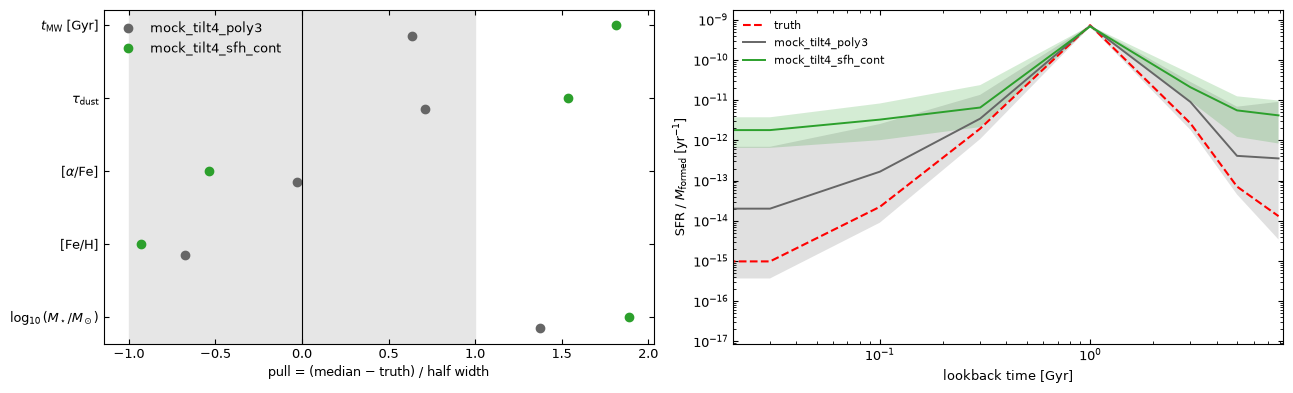

In [16]:
mocks = {a: fits[(a, "M5_172669")] for a in [MOCK_REF] + MOCK_ARMS if (a, "M5_172669") in fits}
if mocks:
    any_fit = next(iter(mocks.values())); truth = any_fit["truth"]; lb = any_fit["sfh"]["lookback_time_gyr"]
    h = 10.0 ** np.concatenate([[0.0], -np.cumsum(truth["logsfr_ratios"])])
    m = 0.5 * (h[:-1] + h[1:]) * np.diff(lb)
    truth_values = {"logmass": truth["logmass"][0], "Z": truth["Z"][0] + FEH_OFFSET, "afe": truth["afe"][0], "tau_dust": truth["diffuse_tau_kc"][0],
                    "age": float((m * 0.5 * (lb[:-1] + lb[1:])).sum() / m.sum())}
    truth_index = float(truth["diffuse_dust_index"][0]) if "diffuse_dust_index" in truth else FIXED_DUST_INDEX
    print("truth dust index:", truth_index)
    rows = []
    for a in mocks:
        r = table.loc[("M5_172669", a)]
        row = {"arm": a, **{k: (r[f"{k}_q50"] - v) / r[f"{k}_hw"] for k, v in truth_values.items()}, **{f"{k}_hw": r[f"{k}_hw"] for k in truth_values}}
        if np.isfinite(r.get("dust_index_q50", np.nan)):
            row["dust_index"] = (r["dust_index_q50"] - truth_index) / r["dust_index_hw"]; row["dust_index_hw"] = r["dust_index_hw"]
        rows.append(row)
    pulls = pd.DataFrame(rows).set_index("arm")
    pulls.to_csv(RESULTS / "mock-new-defaults.csv")
    display(pulls.round(2))
    names = list(truth_values) + (["dust_index"] if "dust_index" in pulls else [])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for i, name in enumerate(names):
        for j, a in enumerate(mocks):
            if name in pulls and np.isfinite(pulls.loc[a].get(name, np.nan)):
                axes[0].plot(pulls.loc[a, name], i + 0.15 * (j - 1), "o", color=COLOURS[a], label=a if i == 0 else None)
    axes[0].axvspan(-1, 1, color="0.9"); axes[0].axvline(0, color="k", lw=0.8)
    axes[0].set_yticks(range(len(names))); axes[0].set_yticklabels([LABELS[k] for k in names])
    axes[0].set_xlabel("pull = (median $-$ truth) / half width"); axes[0].legend(frameon=False)
    w = np.concatenate([[0.5 * np.diff(lb)[0]], 0.5 * (np.diff(lb)[:-1] + np.diff(lb)[1:]), [0.5 * np.diff(lb)[-1]]]) * 1e9
    axes[1].plot(lb, h / np.sum(h * w), "r--", lw=1.5, label="truth")
    for a, fit in mocks.items():
        sfh = fit["sfh"]
        axes[1].plot(lb, sfh["normalized_sfr_q50"], color=COLOURS[a], lw=1.4, label=a)
        axes[1].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=COLOURS[a], alpha=0.2, lw=0)
    axes[1].set(xscale="log", yscale="log", xlabel="lookback time [Gyr]", ylabel=r"SFR / $M_{\rm formed}$ [yr$^{-1}$]")
    axes[1].set_xlim(0.02, lb[-1] * 1.05); axes[1].legend(frameon=False, fontsize=8)
    fig.tight_layout(); fig.savefig(RESULTS / "nd-mock.png", dpi=130); plt.show()

## Wiki figures

- Copy this notebook's PNGs (prefix `nd-`) beside the wiki note.

In [17]:
WIKI_FIGURES.mkdir(parents=True, exist_ok=True)
for png in sorted(RESULTS.glob("nd-*.png")):
    shutil.copy2(png, WIKI_FIGURES / png.name)
sorted(p.name for p in WIKI_FIGURES.glob("nd-*.png"))

['nd-corner-M12_185653.png',
 'nd-corner-M12_98104.png',
 'nd-corner-M1_206545.png',
 'nd-corner-M4_108989.png',
 'nd-corner-M5_172669.png',
 'nd-corner-M5_173928.png',
 'nd-dust-index.png',
 'nd-fit-M12_185653.png',
 'nd-fit-M12_98104.png',
 'nd-fit-M1_206545.png',
 'nd-fit-M4_108989.png',
 'nd-fit-M5_172669.png',
 'nd-fit-M5_173928.png',
 'nd-lick.png',
 'nd-mock.png',
 'nd-parameters-shift.png',
 'nd-sfh-histories.png']